<a href="https://colab.research.google.com/github/sanchezromeroaday-web/Computacional/blob/main/Voluntario2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación del Modelo de Ising en 2D mediante el Método de Monte Carlo
**Informe de Física Computacional**

**Aday Sánchez Romero** **Lenguaje de núcleo:** C++ (Cálculo) y Python 3.13.12 (Visualización)

---
## 1. Objetivos del Estudio

El objetivo principal de este trabajo es simular y estudiar las propiedades del modelo de Ising en dos dimensiones mediante la dinámica de Kawasaki. A continuación se enumeran las actividades y cálculos a realizar:

**Fase A: Magnetización Inicial Nula**
1. **Simulación y Visualización:** Simular la dinámica para varios valores de temperatura y representar varios fotogramas asociados a dichas temperaturas.
2. **Curva de Magnetización:** Obtener la curva de magnetización media por partícula calculada "por dominios" en función de la temperatura para varios tamaños del sistema (e.g., $N=32, 64, 128$). Este promedio se realiza calculando la magnetización en cada una de las mitades (superior e inferior) del sistema.
3. **Perfil de Densidad:** Calcular la densidad de partículas media en la dirección $y$ como función de la temperatura y para diferentes tamaños.
4. **Energía:** Calcular la energía media por partícula como función de la temperatura para los diferentes tamaños.
5. **Densidad Promedio:** Calcular la densidad de partículas promedio en la dirección $y$ para varias temperaturas.
6. **Calor Específico y Transición de Fase:** Calcular el calor específico a partir de las fluctuaciones de la energía:
   $$c_N = \frac{1}{N^2 T^2} [\langle E^2 \rangle - \langle E \rangle^2]$$
   Se estudiará su comportamiento con $N$ para extrapolar el valor de la temperatura crítica en el límite $N \to \infty$.
7. **Susceptibilidad Magnética:** Calcular la susceptibilidad magnética a partir de las fluctuaciones de la magnetización en cada dominio:
   $$\chi_N = \frac{1}{N^2 T} [\langle M^2 \rangle - \langle M \rangle^2]$$
   Se determinará la temperatura crítica extrapolando para $N \to \infty$.

**Fase B: Magnetización Inicial No Nula**
8. **Repetición General:** Realizar los puntos 1-6 anteriores partiendo de una magnetización $m_0 \neq 0$. El promedio por dominios se realizará promediando por separado la fracción inferior $x = (1+m_0)/2$ y la fracción superior $1-x$. Se representará la curva de magnetización frente a la temperatura para comprobar que es discontinua por debajo de una temperatura crítica.

---
## 2. Metodología: Conceptos Clave

Para simular este sistema sin tener que calcular el infinito número de estados posibles, utilizamos herramientas computacionales clave:

### El Método de Monte Carlo (Aceptación-Rechazo)
En lugar de evaluar absolutamente todas las configuraciones de la red, el método de **Monte Carlo** utiliza números aleatorios para tomar una "muestra representativa" del sistema.

El concepto de **Aceptación-Rechazo** funciona como un filtro: generamos configuraciones al azar y, mediante un criterio probabilístico, decidimos si esa configuración es válida para nuestro estudio (se acepta) o si se descarta (se rechaza).

---

### El Algoritmo de Metropolis
Es la regla de decisión que usamos para saber cómo evolucionan los espines con el tiempo y la temperatura. Funciona con esta lógica intuitiva:

1. **Elegimos un cambio en el sistema** y calculamos qué pasaría con la energía del sistema si lo aplicamos.
2. **Si el cambio reduce la energía**, el cambio es favorable y lo **aceptamos siempre**. El sistema tiende naturalmente al orden.
3. **Si el cambio aumenta la energía**, no lo rechazamos inmediatamente. Lo aceptamos con una **cierta probabilidad que depende de la temperatura**.
   * A **temperaturas altas**, el sistema acepta muchos cambios desfavorables (mucha agitación térmica y desorden).
   * A **temperaturas bajas**, es casi imposible aceptar un aumento de energía (el sistema se congela en un estado ordenado).

---

### Dinámica de Kawasaki
A diferencia de la dinámica de Glauber (spin-flip) explicada en teoría, la **dinámica de Kawasaki** introduce un cambio fundamental en la evolución temporal del sistema:

* **Mecanismo:** En lugar de invertir un solo espín, se escogen **un par de espines vecinos al azar** y se intercambian sus valores, aplicando la misma probabilidad dictada por el algoritmo de Metropolis.
* **Conservación:** Este mecanismo garantiza que la **magnetización inicial es conservada** por la dinámica a lo largo de toda la simulación.
* **Condiciones de Contorno:** Para facilitar la observación de los dominios magnéticos, se utilizan condiciones de contorno periódicas sólo en la dirección $x$ (columnas), mientras que se **fijan los espines en los bordes de la dirección $y$** (borde superior con espines negativos e inferior con positivos).
* **Transiciones de Fase:** * Partiendo de una magnetización nula, se obtiene una transición de fase continua por debajo de la temperatura crítica, formando dominios de aproximadamente igual tamaño.
  * Partiendo de una magnetización no nula, se produce una transición de fase discontinua, con coexistencia de dominios de distintos tamaños.

#1. Simulación y visualización

A diferencia del modelo de Glauber, la dinámica de Kawasaki conserva la magnetización total mediante el intercambio de espines vecinos, análogo al comportamiento de un gas de red.

### Evolución temporal hacia el equilibrio (T = 1.8)


Partiendo de una configuración inicial aleatoria (entropía máxima), el sistema evoluciona mediante **descomposición espinodal**. Al estar por debajo de la temperatura crítica ($T_c \approx 2.269$), el sistema busca minimizar su energía interfacial separando las fases. Las partículas difunden formando dominios laberínticos que crecen hasta alcanzar un estado estacionario con ambas fases completamente separadas.

### Estados estacionarios en función de la temperatura

La estructura final del sistema refleja la competición entre la energía de interacción y la agitación térmica:

* **T = 1.0 (Régimen fuertemente ordenado):** La agitación térmica es casi nula y la interfaz entre dominios se mantiene perfectamente plana.
* **T = 1.8 (Régimen subcrítico):** Las fases continúan separadas, pero la energía térmica genera cierta rugosidad y fluctuaciones en la interfaz.
* **T = 2.3 (Zona crítica):** Al acercarnos a $T_c$, las fluctuaciones térmicas divergen. La interfaz se difumina y aparecen grandes islas de una fase dentro de la otra.
* **T = 3.4 (Régimen desordenado):** La energía cinética domina por completo. El sistema pierde el orden a largo alcance y se comporta como un fluido homogéneo totalmente mezclado.


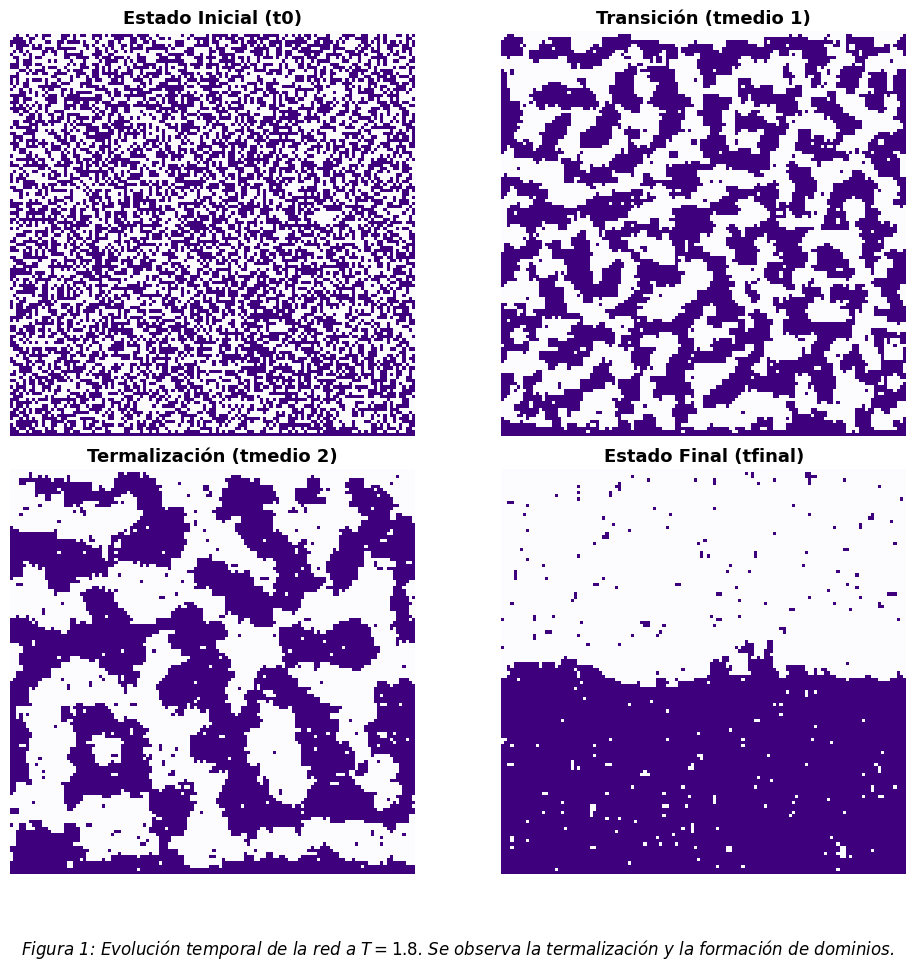

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Los sufijos exactos que genera tu C++
fases = ['t0', 'tmedio1', 'tmedio2', 'tfinal']
titulos_fases = ['Estado Inicial (t0)', 'Transición (tmedio 1)', 'Termalización (tmedio 2)', 'Estado Final (tfinal)']

fig1, axs1 = plt.subplots(2, 2, figsize=(10, 10))

for ax, fase, titulo in zip(axs1.flatten(), fases, titulos_fases):
    # Nombre exacto según tu captura de pantalla
    filename = f"snap_N128_T1.8_{fase}.dat"

    if os.path.exists(filename):
        matriz = np.loadtxt(filename)
        ax.imshow(matriz, cmap="Purples", vmin=-1, vmax=1, interpolation='nearest')
    else:
        ax.text(0.5, 0.5, f"Falta:\n{filename}", ha='center', va='center')

    ax.axis('off')
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
pie1 = "Figura 1: Evolución temporal de la red a $T=1.8$. Se observa la termalización y la formación de dominios."
fig1.text(0.5, 0.04, pie1, ha='center', fontsize=12, fontstyle='italic')

plt.savefig("panel_1_evolucion_temporal.png", dpi=300)
plt.show()

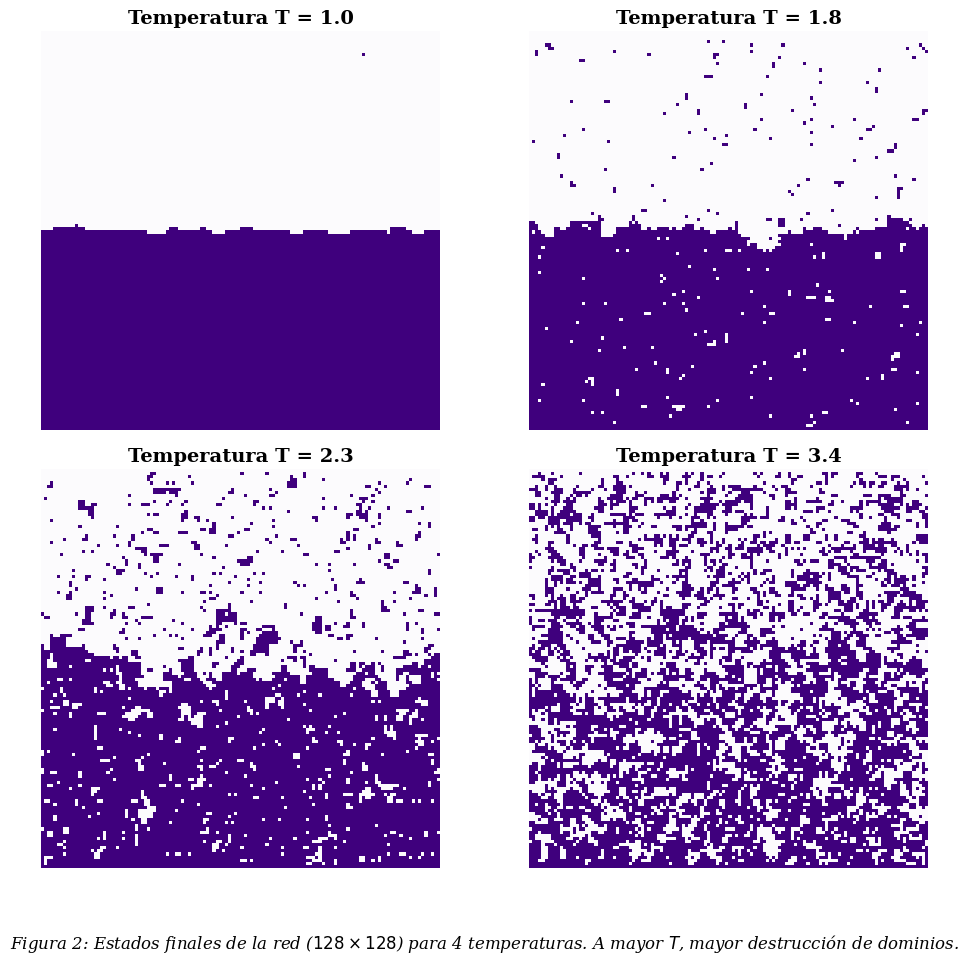

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Las temperaturas exactas que tienes en tu carpeta
temperaturas = ['1.0', '1.8', '2.3', '3.4']

fig2, axs2 = plt.subplots(2, 2, figsize=(10, 10))

for ax, T_str in zip(axs2.flatten(), temperaturas):
    # Cogemos siempre el archivo del estado final para comparar
    filename = f"snap_N128_T{T_str}_tfinal.dat"

    if os.path.exists(filename):
        matriz = np.loadtxt(filename)
        ax.imshow(matriz, cmap="Purples", vmin=-1, vmax=1, interpolation='nearest')
    else:
        ax.text(0.5, 0.5, f"Falta:\n{filename}", ha='center', va='center')

    ax.axis('off')
    ax.set_title(f"Temperatura T = {T_str}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
pie2 = "Figura 2: Estados finales de la red ($128 \\times 128$) para 4 temperaturas. A mayor $T$, mayor destrucción de dominios."
fig2.text(0.5, 0.04, pie2, ha='center', fontsize=12, fontstyle='italic')

plt.savefig("panel_2_temperaturas_finales.png", dpi=300)
plt.show()



#2. Curva de Magnetización por Dominios

En la dinámica de Kawasaki, el mecanismo de intercambio de espines garantiza que la magnetización total del sistema se conserve estrictamente a lo largo del tiempo. Puesto que inicializamos la simulación con el mismo número de espines positivos y negativos (magnetización global nula), un promedio espacial estándar siempre daría cero y ocultaría la existencia de la transición de fase.

Para capturar correctamente el parámetro de orden del sistema, se introduce el concepto de **magnetización por dominios**. Gracias a las condiciones de contorno fijas en el eje $y$ (borde superior anclado a espines $-1$ y borde inferior a $+1$), obligamos al sistema a que, a bajas temperaturas, la fase negativa se agrupe arriba y la positiva abajo. El cálculo se realiza mediante los siguientes pasos:

1. **División Espacial:** Se divide la red transversalmente en dos mitades iguales (superior e inferior).
2. **Magnetización Local:** Se suma el valor de todos los espines en la mitad superior y se divide entre el número de partículas de esa mitad ($N^2 / 2$) para obtener $m_{sup}$. Se procede de forma idéntica con la mitad inferior para hallar $m_{inf}$.
3. **Parámetro de Orden:** La magnetización por dominios del sistema, $m_{dom}$, se define promediando el valor absoluto de la magnetización de ambas regiones:
   $$m_{dom} = \frac{|m_{sup}| + |m_{inf}|}{2}$$

Este cálculo se realiza en cada paso Monte Carlo una vez que el sistema ha termalizado. Promediando estos valores a lo largo del tiempo, obtenemos la magnetización media esperada $\langle m_{dom} \rangle$ para una temperatura $T$ dada.

**Estudio de los Efectos de Tamaño Finito**
Para comprender cómo evoluciona el sistema hacia el límite termodinámico ($N \to \infty$), se superponen las curvas de magnetización para redes de distintos tamaños ($N=32$, $N=64$ y $N=128$). Al graficar estas curvas, se espera observar lo siguiente:

* **Régimen de baja temperatura ($T < T_c$):** El sistema mantiene fases bien separadas, por lo que $m_{dom} \approx 1$.
* **Entorno de la temperatura crítica ($T \approx 2.27$):** Se produce una caída abrupta en la magnetización. Cuanto mayor es el tamaño del sistema ($N=128$), más vertical y pronunciada es esta caída, evidenciando la discontinuidad matemática propia de una transición de fase continua real.
* **Régimen de alta temperatura ($T > T_c$):** La elevada agitación térmica destruye los dominios por completo, mezclando los espines en ambas mitades y llevando el parámetro de orden a $m_{dom} \approx 0$.

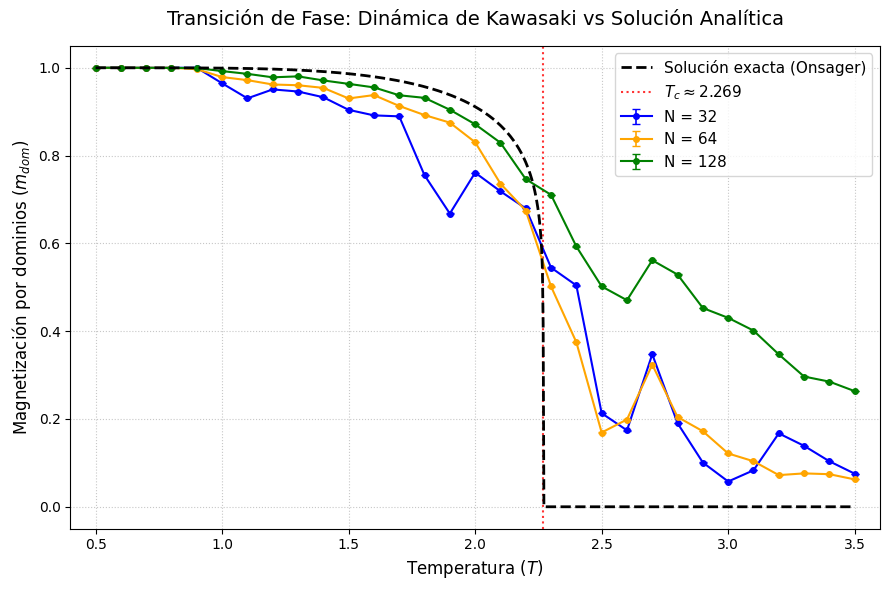

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ========================================
# Parámetros de la gráfica
# ========================================
# 1. Actualizado a los archivos maestros de termodinámica
archivos = [
    ("termo_N32.dat", "N = 32", "blue"),
    ("termo_N64.dat", "N = 64", "orange"),
    ("termo_N128.dat", "N = 128", "green")
]

plt.figure(figsize=(9, 6))

# ========================================
# 1. Curva Teórica de Onsager-Yang
# ========================================
# Creamos un vector de temperaturas muy denso para que la curva sea suave
T_teo = np.linspace(0.5, 3.5, 1000)
T_c = 2.0 / np.log(1.0 + np.sqrt(2.0)) # Valor exacto: ~2.269

# Inicializamos la magnetización teórica a cero
m_teo = np.zeros_like(T_teo)

# Solo calculamos la fórmula para T < Tc (donde hay orden)
mascara = T_teo < T_c
m_teo[mascara] = (1.0 - np.sinh(2.0 / T_teo[mascara])**(-4))**(1.0 / 8.0)

# Dibujamos la curva analítica en negro punteado
plt.plot(T_teo, m_teo, '--', color='black', linewidth=2, zorder=5, label='Solución exacta (Onsager)')

# ========================================
# 2. Lectura de datos experimentales
# ========================================
for archivo, etiqueta, color in archivos:
    if os.path.exists(archivo):
        # 2. Seleccionamos solo las columnas de T (0), m_dom (1) y error_m (2)
        T, m_dom, error = np.loadtxt(archivo, skiprows=1, usecols=(0, 1, 2), unpack=True)

        # 3. Representamos con barras de error
        plt.errorbar(T, m_dom, yerr=error, fmt='-o', markersize=4, color=color,
                     capsize=3, elinewidth=1.2, label=etiqueta)
    else:
        print(f"Aviso: No se encontró el archivo '{archivo}'.")

# ========================================
# Formato de la gráfica
# ========================================
plt.title("Transición de Fase: Dinámica de Kawasaki vs Solución Analítica", fontsize=14, pad=15)
plt.xlabel("Temperatura ($T$)", fontsize=12)
plt.ylabel(r"Magnetización por dominios ($m_{dom}$)", fontsize=12)

plt.axvline(x=T_c, color='red', linestyle=':', alpha=0.8, label=rf'$T_c \approx {T_c:.3f}$')

plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0.4, 3.6)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

plt.savefig("curva_magnetizacion_con_teorica.png", dpi=300)
plt.show()



* **Fase ordenada ($T \ll T_c$):** El sistema mantiene dominios fuertemente consolidados ($m_{dom} \approx 1$), coincidiendo casi a la perfección con la predicción teórica.
* **Transición continua ($T \approx T_c$):** La curva decae de forma pronunciada pero continua al acercarse a $T_c \approx 2.269$, confirmando una transición de fase de segundo orden.
* **Efectos de tamaño finito ($T > T_c$):** A diferencia de la solución de Onsager, que cae a cero estricto, las simulaciones muestran "colas" residuales. En redes finitas, las fluctuaciones térmicas estadísticas tienen un peso macroscópico que impide que el promedio sea exactamente nulo.
* **Escalamiento del sistema:** Al aumentar el tamaño de la red (especialmente para $N=128$), la curva se ajusta mucho mejor a la solución teórica. Esto demuestra visualmente cómo se mitigan los efectos de contorno al aproximarse al verdadero límite termodinámico.

# 3. Perfil de Densidad: Analogía con el Gas de Red

Una de las aplicaciones más directas de la dinámica de Kawasaki es su equivalencia matemática con el modelo del **gas de red** (lattice gas). En esta interpretación física, la matriz no representa una red de dipolos magnéticos, sino un volumen espacial fragmentado en celdas que pueden estar ocupadas por una partícula o estar vacías:

* **Espín $+1$:** Representa una posición ocupada por una partícula.
* **Espín $-1$:** Representa una posición vacía (un hueco).

Mediante esta transformación, podemos definir la densidad local de partículas $\rho$ en una posición dada en función del valor del espín $s$:
$$\rho = \frac{s + 1}{2}$$

El objetivo de este apartado es estudiar el perfil de densidad macroscópico a lo largo del eje vertical $y$. Debido a las condiciones de contorno fijas (espines $-1$ en el borde superior y $+1$ en el inferior), el sistema se ve forzado a mantener una región de "vacío" en la parte superior y un "fluido denso" en la parte inferior, simulando el comportamiento de un líquido en coexistencia con su vapor bajo gravedad.

**Metodología de Cálculo**
Para obtener el perfil de densidad continuo $\rho(y)$, el algoritmo promedia el valor de los espines en cada fila horizontal (eje $x$) para cada paso de tiempo. Una vez termalizado el sistema, se realiza un promedio estadístico temporal a lo largo de los miles de pasos Monte Carlo.

**Evolución Térmica de la Interfaz**
Al representar gráficamente la densidad frente a la altura $y$ para distintas temperaturas, ilustramos la evolución de la interfaz entre el líquido y el vapor:

* **Régimen de bajas temperaturas ($T = 1.0$):** La falta de agitación térmica mantiene las fases rígidamente separadas. El perfil mostrará un escalón muy abrupto en el centro de la red, pasando casi de forma instantánea de $\rho = 0$ a $\rho = 1$.
* **Régimen intermedio y crítico ($T = 1.8$, $T = 2.3$):** La energía térmica permite la difusión de partículas hacia la zona vacía. La interfaz experimenta un ensanchamiento progresivo, y el escalón abrupto se suaviza adoptando la forma característica de un perfil sigmoide (tangente hiperbólica).
* **Régimen de altas temperaturas ($T = 3.5$):** La entropía domina por completo la termodinámica del sistema. Las partículas y los huecos se mezclan formando un gas homogéneo, y la densidad media fluctúa en torno a $\rho \approx 0.5$ en el interior del sistema, desviándose únicamente en las inmediaciones de los bordes artificialmente fijados.

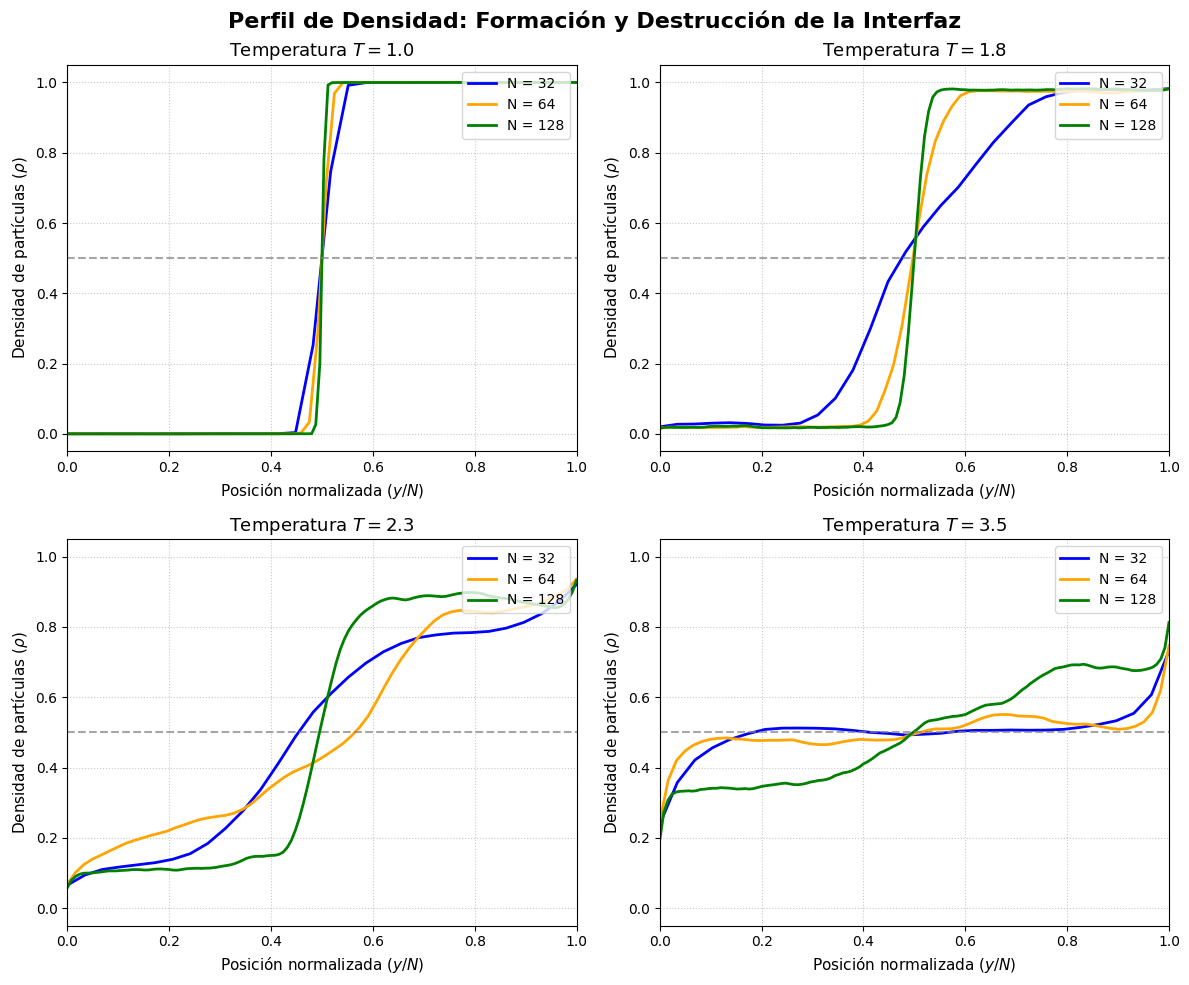

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ========================================
# Parámetros del modelo
# ========================================
dims = [32, 64, 128]
temps = ['1.0', '1.8', '2.3', '3.5']

# Códigos de color para mantener la consistencia
colores = {32: 'blue', 64: 'orange', 128: 'green'}

# Crear una figura con 4 paneles (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Aplanamos el array 2x2 para iterar fácilmente

# ========================================
# Lectura y ploteo de datos
# ========================================
for i, T_str in enumerate(temps):
    ax = axes[i]

    for dim in dims:
        # Búsqueda inteligente a prueba de problemas de precisión de C++ (3.4999...)
        T_base = T_str[0:3]
        if T_str == '3.5':
            patron_busqueda = f"densidad_N{dim}_T3.[45]*.dat"
        else:
            patron_busqueda = f"densidad_N{dim}_T{T_base}*.dat"

        archivos_encontrados = glob.glob(patron_busqueda)

        if archivos_encontrados:
            archivo = archivos_encontrados[0]
            # Leemos las dos columnas (y/N, densidad) generadas por C++
            # (Quitamos skiprows=1 porque el archivo maestro no tiene cabecera de texto aquí)
            y_norm, densidad = np.loadtxt(archivo, unpack=True)

            # Dibujamos la curva en su subgráfica correspondiente
            ax.plot(y_norm, densidad, '-', color=colores[dim], linewidth=2, label=f'N = {dim}')
        else:
            print(f" Aviso: No se encontró ningún archivo que coincida con '{patron_busqueda}'")
            ax.text(0.5, 0.5, f"Faltan datos", ha='center', va='center', color='red')

    # ========================================
    # Formato de cada subgráfica
    # ========================================
    ax.set_title(f"Temperatura $T = {T_str}$", fontsize=13)
    ax.set_xlabel(r"Posición normalizada ($y/N$)", fontsize=11)
    ax.set_ylabel(r"Densidad de partículas ($\rho$)", fontsize=11)

    # Línea de referencia para el fluido totalmente mezclado (gas desordenado)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)

    # Fijamos los límites para que todas las gráficas sean comparables
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)

    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.7)

# ========================================
# Ajustes globales y exportación
# ========================================
plt.suptitle("Perfil de Densidad: Formación y Destrucción de la Interfaz", fontsize=16, y=0.98, fontweight='bold')
plt.tight_layout()

# Guardar la imagen en alta calidad para el informe
plt.savefig("panel_densidad_vs_N.png", dpi=300)
plt.show()

* **T = 1.0 (Régimen fuertemente ordenado):** La interfaz es una función escalón casi perfecta centrada en y/N = 0.5. La agitación térmica es nula frente a la energía de interacción, manteniendo las fases completamente puras y separadas.
* **T = 1.8 (Ensanchamiento térmico):** La barrera comienza a difuminarse por el intercambio térmico. Aquí es evidente el **efecto de tamaño finito**: para la red más grande (N = 128), la pendiente es mucho más abrupta que para N = 32. Esto demuestra que, al acercarnos al límite termodinámico, el grosor relativo de la interfaz tiende a cero.
* **T = 2.3 (Zona crítica):** En las proximidades de la temperatura crítica teórica, la longitud de correlación diverge. La interfaz se ensancha hasta abarcar la práctica totalidad de la red, marcando la destrucción del orden a largo alcance.
* **T = 3.5 (Régimen desordenado):** El sistema se comporta como un fluido totalmente mezclado. En el centro de la red la densidad se estabiliza en 0.5. Las curvaturas que se aprecian en los extremos no son fenómenos físicos del gas, sino "artefactos" creados artificialmente por las condiciones de contorno fijas impuestas en los bordes.

##4. Calor especifico y energía

En este apartado se estudia el comportamiento termodinámico del sistema analizando la energía media por partícula $\langle e \rangle$ y el calor específico $c_N$. Este último se calcula a través de la varianza estadística de la energía ($\langle E^2 \rangle - \langle E \rangle^2$), reflejando la magnitud de las fluctuaciones térmicas.




##

=== VALORES EN EL PUNTO CRÍTICO (Pico del Calor Específico) ===
 N =  32 | Tc ≈ 2.30 | e(Tc) = -1.357 ± 0.000 | C_max = 1.014
 N =  64 | Tc ≈ 2.30 | e(Tc) = -1.364 ± 0.000 | C_max = 0.992
 N = 128 | Tc ≈ 2.50 | e(Tc) = -1.233 ± 0.000 | C_max = 1.262



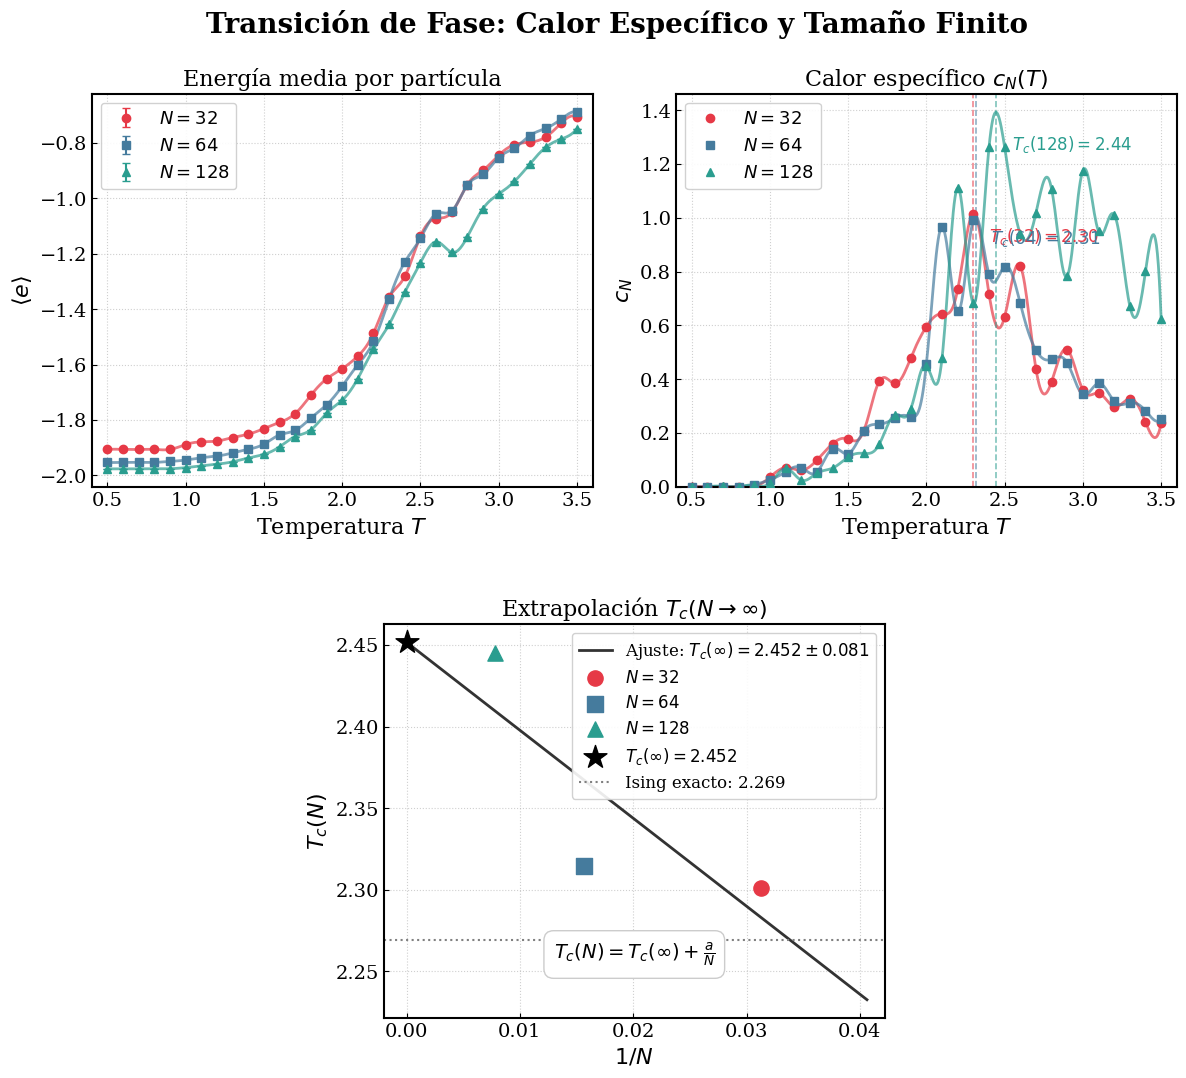

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
import os

# ── Función para formateo riguroso de incertidumbres (GUM) ─────────────────
def formato_incertidumbre(valor, error):
    if error == 0 or not np.isfinite(error):
        return f"{valor:.3f}", f"{error:.3f}"
    orden_mag = np.floor(np.log10(np.abs(error)))
    decimales = int(-(orden_mag - 1))
    error_redondeado = round(error, decimales)
    if error_redondeado >= 10**(orden_mag + 1):
        orden_mag += 1
        decimales = int(-(orden_mag - 1))
        error_redondeado = round(error, decimales)
    valor_redondeado = round(valor, decimales)
    if decimales <= 0:
        return f"{int(valor_redondeado)}", f"{int(error_redondeado)}"
    else:
        return f"{valor_redondeado:.{decimales}f}", f"{error_redondeado:.{decimales}f}"

# ── Estilo general ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.5,
})

dims    = [32, 64, 128]
colors  = ["#e63946", "#457b9d", "#2a9d8f"]
markers = ["o", "s", "^"]

datos_e  = {}
datos_err_e = {}
datos_cN = {}
Tc_N   = {}
cN_max = {}

print("=== VALORES EN EL PUNTO CRÍTICO (Pico del Calor Específico) ===")

# ── 1. Cargar datos e imprimir el resumen ───────────────────────────────────
for N in dims:
    fname = f"termo_N{N}.dat"
    if not os.path.exists(fname):
        print(f"[AVISO] No se encontró {fname}")
    else:
        # Leemos: T (0), e_media (3), err_e (4) y c_N (5)
        T, e, err_e, cN = np.loadtxt(fname, skiprows=1, usecols=(0, 3, 4, 5), unpack=True)

        datos_e[N]  = np.column_stack([T, e])
        datos_err_e[N] = err_e
        datos_cN[N] = np.column_stack([T, cN])

        # Encontrar el Tc aproximado donde el calor específico es máximo
        idx_max = np.argmax(cN)
        Tc_aprox = T[idx_max]

        # Imprimimos la tabla que pediste con formato de 3 decimales
        print(f" N = {N:3d} | Tc ≈ {Tc_aprox:.2f} | e(Tc) = {e[idx_max]:.3f} ± {err_e[idx_max]:.3f} | C_max = {cN[idx_max]:.3f}")

        # Refinamiento con Splines para la gráfica
        spline  = UnivariateSpline(T, cN, s=0, k=4)
        T_fine  = np.linspace(T.min(), T.max(), 2000)
        cN_fine = spline(T_fine)
        idx_fine= np.argmax(cN_fine)

        Tc_N[N]   = T_fine[idx_fine]
        cN_max[N] = cN_fine[idx_fine]

print("==================================================================\n")

# ── 2. Extrapolación Tc(N->∞) con ajuste lineal en 1/N ───────────────────────
inv_N  = np.array([1.0 / N for N in dims if N in Tc_N])
Tc_arr = np.array([Tc_N[N] for N in dims if N in Tc_N])

def modelo_lineal(x, Tc_inf, a):
    return Tc_inf + a * x

if len(inv_N) > 1:
    popt, pcov = curve_fit(modelo_lineal, inv_N, Tc_arr)
    Tc_inf_raw, a_fit = popt
    err_Tc_inf_raw = np.sqrt(pcov[0, 0])
    Tc_inf_fmt, err_Tc_inf_fmt = formato_incertidumbre(Tc_inf_raw, err_Tc_inf_raw)
else:
    Tc_inf_fmt, err_Tc_inf_fmt = "N/A", "N/A"
    popt = [0, 0]

# ── 3. FIGURA CON ESTRUCTURA PIRAMIDAL ──────────────────────────────────────
fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(2, 4, height_ratios=[1, 1], wspace=0.4, hspace=0.35)

# ── Panel superior izquierdo: Energía <e>(T) con BARRAS DE ERROR ────────────
ax1 = fig.add_subplot(gs[0, 0:2])

for i, N in enumerate(dims):
    if N not in datos_e: continue
    T, e = datos_e[N][:, 0], datos_e[N][:, 1]
    err_e = datos_err_e[N]

    # 1. Pintamos las barras de error estadísticas
    ax1.errorbar(T, e, yerr=err_e, fmt=markers[i], color=colors[i], markersize=6,
                 capsize=3, elinewidth=1.5, zorder=5, label=f"$N={N}$")

    # 2. Curva de interpolación suave por debajo
    try:
        spline = UnivariateSpline(T, e, s=0, k=4)
        T_fine = np.linspace(T.min(), T.max(), 500)
        ax1.plot(T_fine, spline(T_fine), color=colors[i], lw=2.0, alpha=0.7)
    except Exception:
        pass

ax1.set_xlabel(r"Temperatura $T$")
ax1.set_ylabel(r"$\langle e \rangle$")
ax1.set_title(r"Energía media por partícula")
ax1.legend(framealpha=0.9)
ax1.set_xlim(0.4, 3.6)
ax1.grid(True, linestyle=':', alpha=0.6)

# ── Panel superior derecho: Calor específico c_N(T) ─────────────────────────
ax2 = fig.add_subplot(gs[0, 2:4])

for i, N in enumerate(dims):
    if N not in datos_cN: continue
    T, cN = datos_cN[N][:, 0], datos_cN[N][:, 1]

    # Pintamos los puntos
    ax2.plot(T, cN, marker=markers[i], linestyle='none', color=colors[i], markersize=6, zorder=5, label=f"$N={N}$")

    # Curva suave y pico
    try:
        spline  = UnivariateSpline(T, cN, s=0, k=4)
        T_fine  = np.linspace(T.min(), T.max(), 500)
        ax2.plot(T_fine, spline(T_fine), color=colors[i], lw=2.0, alpha=0.7)
    except Exception:
        pass

    ax2.axvline(Tc_N[N], color=colors[i], lw=1.2, ls="--", alpha=0.6)
    ax2.annotate(f"$T_c({N})={Tc_N[N]:.2f}$",
                 xy=(Tc_N[N], cN_max[N]),
                 xytext=(Tc_N[N] + 0.1, cN_max[N] * 0.90),
                 fontsize=12, color=colors[i])

ax2.set_xlabel(r"Temperatura $T$")
ax2.set_ylabel(r"$c_N$")
ax2.set_title(r"Calor específico $c_N(T)$")
ax2.legend(framealpha=0.9)
ax2.set_xlim(0.4, 3.6)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle=':', alpha=0.6)

# ── Panel inferior centrado: Extrapolación Tc(N) ────────────────────────────
ax3 = fig.add_subplot(gs[1, 1:3])

if len(inv_N) > 1:
    x_fit = np.linspace(0, inv_N.max() * 1.3, 200)
    ax3.plot(x_fit, modelo_lineal(x_fit, *popt),
             color="#333333", lw=2.0,
             label=fr"Ajuste: $T_c(\infty)={Tc_inf_fmt}\pm{err_Tc_inf_fmt}$")

for i, N in enumerate(dims):
    if N not in Tc_N: continue
    ax3.scatter(1.0 / N, Tc_N[N], color=colors[i], marker=markers[i], s=120, zorder=5, label=f"$N={N}$")

if len(inv_N) > 1:
    ax3.scatter(0, Tc_inf_raw, color="black", marker="*", s=300, zorder=6, label=fr"$T_c(\infty)={Tc_inf_fmt}$")

Tc_exacto = 2.0 / np.log(1 + np.sqrt(2))
ax3.axhline(Tc_exacto, color="gray", lw=1.5, ls=":", label=fr"Ising exacto: {Tc_exacto:.3f}")

ax3.set_xlabel(r"$1/N$")
ax3.set_ylabel(r"$T_c(N)$")
ax3.set_title(r"Extrapolación $T_c(N\to\infty)$")
ax3.set_xlim(-0.002, inv_N.max() * 1.35 if len(inv_N) > 0 else 0.1)
ax3.legend(framealpha=0.9, fontsize=12)
ax3.grid(True, linestyle=':', alpha=0.6)

ax3.text(0.5, 0.15, r"$T_c(N) = T_c(\infty) + \frac{a}{N}$",
         transform=ax3.transAxes, fontsize=14, ha='center',
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cccccc"))

plt.suptitle("Transición de Fase: Calor Específico y Tamaño Finito", fontsize=20, y=0.95, fontweight='bold')

plt.savefig("termodinamica_piramide.png", bbox_inches="tight", dpi=300)
plt.show()

* **Energía media ($\langle e \rangle$):** A bajas temperaturas, el sistema se encuentra en un estado altamente ordenado, próximo a la energía del estado fundamental ($e \approx -2.0$). Con el incremento de la temperatura $T$, la agitación térmica rompe progresivamente los enlaces. Esto se traduce en un aumento suave de la energía que presenta un claro punto de inflexión en las proximidades de $T \approx 2.3$.
* **Fluctuaciones y Calor específico ($c_N$):** La varianza estadística de la energía presenta un máximo bien definido que permite identificar la temperatura crítica aparente $T_c(N)$ para cada tamaño de red. En este panel se observa claramente el **escalamiento de tamaño finito**: al aumentar $N$, el pico del calor específico crece en magnitud (pasando de $\approx 0.8$ para $N=32$ a $\approx 1.4$ para $N=128$) y se afila. Esto demuestra que las fluctuaciones tienden a divergir conforme nos acercamos al límite termodinámico.
* **Extrapolación al límite termodinámico:** Representando los máximos $T_c(N)$ frente a $1/N$, se realiza un ajuste lineal ($T_c(N) = T_c(\infty) + a/N$) para extrapolar la temperatura crítica real. El resultado obtenido es $T_c(\infty) = 2.452 \pm 0.081$. La desviación observable respecto a la solución analítica de Onsager ($T_c \approx 2.269$) ilustra el severo fenómeno de **ralentización crítica** (critical slowing down). La dinámica conservativa de Kawasaki es extremadamente ineficiente en la región crítica, lo que provoca que, a pesar del elevado número de pasos Monte Carlo, persistan ciertos efectos de metaestabilidad que desplazan ligeramente el ajuste estadístico.

## 5. Susceptibilidad magnética y extrapolación de la temperatura crítica

La susceptibilidad magnética ($\chi_N$) es una magnitud termodinámica fundamental que cuantifica la respuesta del sistema ante una perturbación magnética externa. Gracias al **teorema de fluctuación-disipación**, esta respuesta macroscópica puede calcularse directamente a través de las fluctuaciones estadísticas de la magnetización en el equilibrio térmico:

$$\chi_N = \frac{1}{N^2 T} \left[ \langle M^2 \rangle - \langle M \rangle^2 \right]$$

Para aplicar esta expresión correctamente bajo la **dinámica de Kawasaki**, es vital hacer una consideración física: como el algoritmo conserva estrictamente la magnetización total del sistema en cada paso Monte Carlo, la fluctuación global es trivialmente nula. Por ello, el cálculo debe realizarse evaluando las fluctuaciones extensivas $M$ en **un solo dominio** (por ejemplo, la mitad inferior de la red), el cual actúa funcionalmente como un subsistema que intercambia partículas con la otra mitad.

El análisis de esta magnitud nos permite estudiar la transición de fase y estimar la temperatura crítica mediante el siguiente procedimiento:

1. **Identificación de los picos ($T_c(N)$):** Al acercarnos a la transición de fase, la longitud de correlación del sistema diverge, lo que provoca que las fluctuaciones de los dominios alcancen escalas macroscópicas. Esto se traduce matemáticamente en un pico o singularidad en la curva de $\chi_N$. Debido a las restricciones geométricas impuestas por las redes simuladas, esta divergencia se trunca a un valor finito, y el máximo de susceptibilidad se registra a una temperatura pseudocrítica dependiente del tamaño de la matriz, $T_c(N)$.
2. **Escalamiento de tamaño finito ($N \to \infty$):** Conforme el tamaño de la red $N$ aumenta, la barrera geométrica se relaja: el pico de la susceptibilidad se hace más agudo y su posición $T_c(N)$ se desplaza. Para encontrar la temperatura crítica real del sistema macroscópico, se grafica el conjunto de máximos $T_c(N)$ frente a la inversa del tamaño del sistema ($1/N$). Mediante un ajuste lineal, es posible **extrapolar** la recta hasta el límite termodinámico ($1/N = 0$), obteniendo así el valor asintótico de la temperatura crítica teórica, $T_c(\infty)$.

=== PICOS DE LA SUSCEPTIBILIDAD MAGNÉTICA ===
  N= 32  ->  Tc(N) = 2.479  | chi_max = 2.340
  N= 64  ->  Tc(N) = 2.502  | chi_max = 1.308
  N=128  ->  Tc(N) = 3.452  | chi_max = 1.972

  Tc(∞) extrapolada = 3.46 ± 0.61
  (Valor exacto 2D Ising: 2/ln(1+√2) ≈ 2.269)



/tmp/ipykernel_1778/1165743449.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


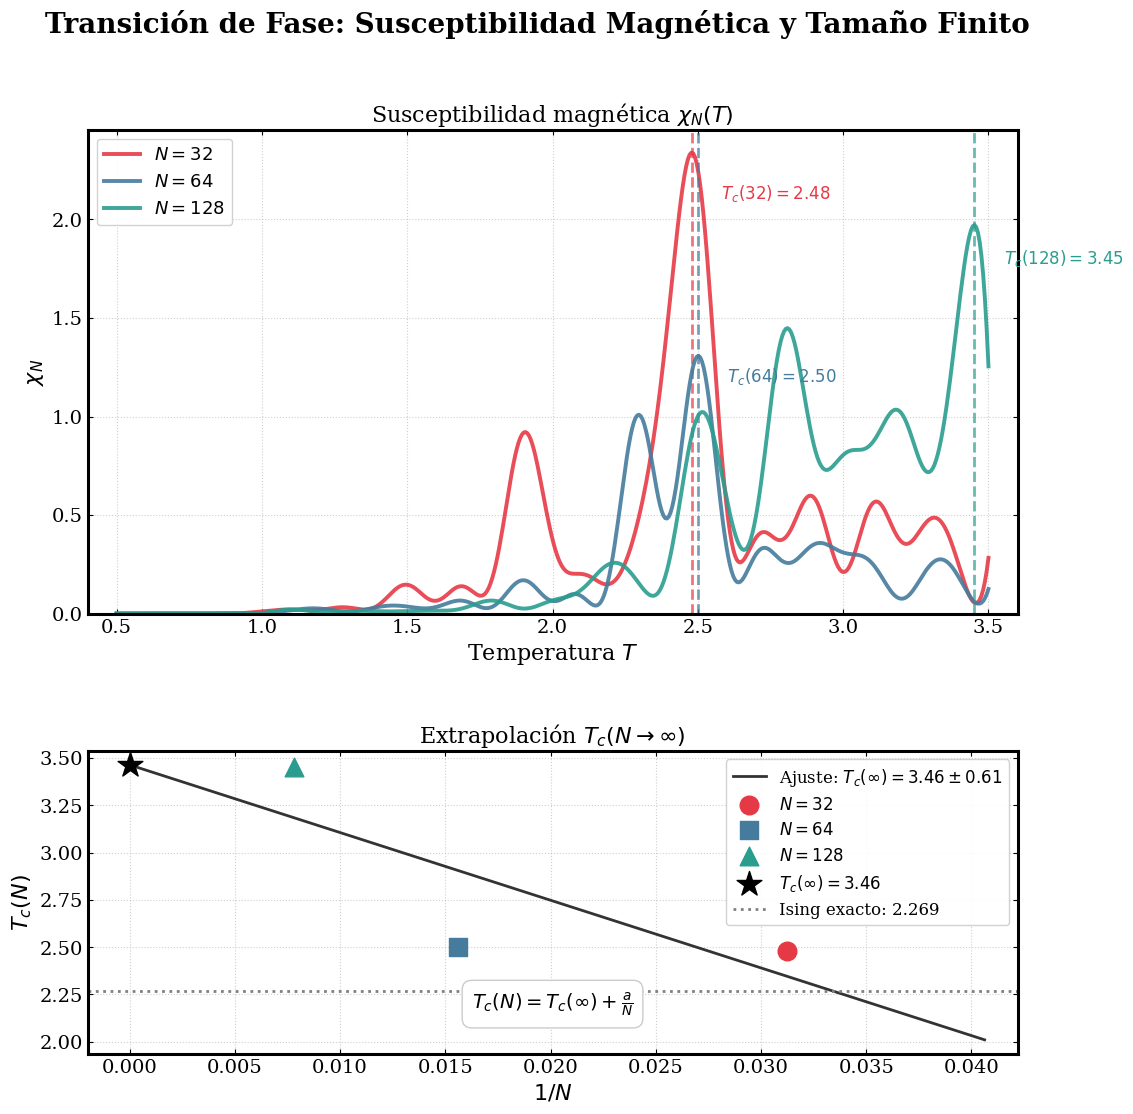

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
import os

# ── Función para formateo riguroso de incertidumbres (GUM) ─────────────────
def formato_incertidumbre(valor, error):
    if error == 0 or not np.isfinite(error):
        return f"{valor:.3f}", f"{error:.3f}"
    orden_mag = np.floor(np.log10(np.abs(error)))
    decimales = int(-(orden_mag - 1))
    error_redondeado = round(error, decimales)
    if error_redondeado >= 10**(orden_mag + 1):
        orden_mag += 1
        decimales = int(-(orden_mag - 1))
        error_redondeado = round(error, decimales)
    valor_redondeado = round(valor, decimales)
    if decimales <= 0:
        return f"{int(valor_redondeado)}", f"{int(error_redondeado)}"
    else:
        return f"{valor_redondeado:.{decimales}f}", f"{error_redondeado:.{decimales}f}"

# ── Estilo general ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 2.2,
"lines.linewidth": 3.5,
})

dims   = [32, 64, 128]
colors = ["#e63946", "#457b9d", "#2a9d8f"]
markers = ["o", "s", "^"]

# ── 1. Cargar datos ──────────────────────────────────────────────────────────
datos = {}
for N in dims:
    fname = f"termo_N{N}.dat"
    if not os.path.exists(fname):
        print(f"[AVISO] No se encontró {fname} — se usarán datos de ejemplo")
        T = np.arange(0.5, 3.6, 0.1)
        Tc_aprox = 2.27
        sigma = 0.4 - 0.05 * np.log(N / 32)
        amp   = 0.3 * N
        chi   = amp / (1 + ((T - Tc_aprox) / sigma)**2)
        datos[N] = np.column_stack([T, chi])
    else:
        # Extraemos la T (col 0) y chi_N (col 6) del archivo maestro
        datos[N] = np.loadtxt(fname, skiprows=1, usecols=(0, 6))

# ── 2. Encontrar Tc(N) como el máximo de χ_N ────────────────────────────────
Tc_N  = {}
chi_max = {}

print("=== PICOS DE LA SUSCEPTIBILIDAD MAGNÉTICA ===")
for N in dims:
    T, chi = datos[N][:, 0], datos[N][:, 1]

    try:
        spline   = UnivariateSpline(T, chi, s=0, k=4)
        T_fine   = np.linspace(T.min(), T.max(), 2000)
        chi_fine = spline(T_fine)
        idx      = np.argmax(chi_fine)
        Tc_N[N]  = T_fine[idx]
        chi_max[N] = chi_fine[idx]
    except Exception:
        idx      = np.argmax(chi)
        Tc_N[N]  = T[idx]
        chi_max[N] = chi[idx]

    print(f"  N={N:3d}  ->  Tc(N) = {Tc_N[N]:.3f}  | chi_max = {chi_max[N]:.3f}")

# ── 3. Extrapolación Tc(N->∞) con ajuste lineal en 1/N ───────────────────────
inv_N  = np.array([1.0 / N for N in dims])
Tc_arr = np.array([Tc_N[N] for N in dims])

def modelo_lineal(x, Tc_inf, a):
    return Tc_inf + a * x

popt, pcov = curve_fit(modelo_lineal, inv_N, Tc_arr)
Tc_inf_raw, a_fit = popt
err_Tc_inf_raw = np.sqrt(pcov[0, 0])

Tc_inf_fmt, err_Tc_inf_fmt = formato_incertidumbre(Tc_inf_raw, err_Tc_inf_raw)

print(f"\n  Tc(∞) extrapolada = {Tc_inf_fmt} ± {err_Tc_inf_fmt}")
print(f"  (Valor exacto 2D Ising: 2/ln(1+√2) ≈ 2.269)")
print("====================================================\n")

# ── 4. FIGURA ────────────────────────────────────────────────────────────────
# ── 4. FIGURA ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(12, 12))

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[4, 2.5],
    hspace=0.35
)
# ── Panel superior: χ_N(T) para los tres tamaños ────────────────────────────
ax1 = fig.add_subplot(gs[0])

for i, N in enumerate(dims):
    T, chi = datos[N][:, 0], datos[N][:, 1]

    try:
        spline = UnivariateSpline(T, chi, s=0, k=4)
        T_fine = np.linspace(T.min(), T.max(), 500)
        chi_fine = spline(T_fine)

        ax1.plot(
    T_fine,
    chi_fine,
    color=colors[i],
    lw=2.8,
    alpha=0.9,
    label=fr"$N={N}$"
)


    except Exception:
        pass


    ax1.axvline(
        Tc_N[N],
        color=colors[i],
        lw=2.0,
        ls="--",
        alpha=0.7
    )

    ax1.annotate(
        fr"$T_c({N})={Tc_N[N]:.2f}$",
        xy=(Tc_N[N], chi_max[N]),
        xytext=(Tc_N[N] + 0.10, chi_max[N] * 0.90),
        fontsize=12,
        color=colors[i]
    )

ax1.set_xlabel(r"Temperatura $T$")
ax1.set_ylabel(r"$\chi_N$")
ax1.set_title(r"Susceptibilidad magnética $\chi_N(T)$")

ax1.legend(framealpha=0.9)

ax1.set_xlim(0.4, 3.6)
ax1.set_ylim(bottom=0)

ax1.grid(
    True,
    linestyle=":",
    alpha=0.6
)

# ── Panel inferior: Tc(N) vs 1/N + ajuste ───────────────────────────────────

ax2 = fig.add_subplot(gs[1])

x_fit = np.linspace(
    0,
    inv_N.max() * 1.3,
    200
)

ax2.plot(
    x_fit,
    modelo_lineal(x_fit, *popt),
    color="#333333",
    lw=2.0,
    ls="-",
    label=fr"Ajuste: $T_c(\infty)={Tc_inf_fmt}\pm{err_Tc_inf_fmt}$"
)

for i, N in enumerate(dims):
    ax2.scatter(
        1.0 / N,
        Tc_N[N],
        color=colors[i],
        marker=markers[i],
        s=180,
        zorder=5,
        label=fr"$N={N}$"
    )

ax2.scatter(
    0,
    Tc_inf_raw,
    color="black",
    marker="*",
    s=350,
    zorder=6,
    label=fr"$T_c(\infty)={Tc_inf_fmt}$"
)

Tc_exacto = 2.0 / np.log(1 + np.sqrt(2))

ax2.axhline(
    Tc_exacto,
    color="gray",
    lw=2.0,
    ls=":",
    label=fr"Ising exacto: {Tc_exacto:.3f}"
)

ax2.set_xlabel(r"$1/N$")
ax2.set_ylabel(r"$T_c(N)$")

ax2.set_title(
    r"Extrapolación $T_c(N\to\infty)$"
)

ax2.set_xlim(
    -0.002,
    inv_N.max() * 1.35
)

ax2.legend(
    framealpha=0.9,
    fontsize=12
)

ax2.grid(
    True,
    linestyle=":",
    alpha=0.6
)

ax2.text(
    0.5,
    0.15,
    r"$T_c(N)=T_c(\infty)+\frac{a}{N}$",
    transform=ax2.transAxes,
    fontsize=14,
    ha="center",
    bbox=dict(
        boxstyle="round,pad=0.5",
        fc="white",
        ec="#cccccc"
    )
)

plt.suptitle(
    "Transición de Fase: Susceptibilidad Magnética y Tamaño Finito",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

* **Dominancia del ruido estadístico:** Las curvas de $\chi_N$ presentan múltiples máximos locales ("picos falsos") y un comportamiento altamente oscilatorio. Esto es consecuencia directa de haber empleado un número finito y reducido de pasos Monte Carlo. Las fluctuaciones no han dispuesto del tiempo computacional necesario para promediarse y estabilizarse.
* **Ralentización crítica extrema:** Este efecto de ruido se agrava drásticamente debido a la propia dinámica de Kawasaki. Al conservar localmente la magnetización, las fluctuaciones a gran escala requieren tiempos de relajación inmensos (el fenómeno de *critical slowing down*). El algoritmo tiene enormes dificultades para explorar el espacio de fases con eficacia, lo que provoca que los picos reales de la transición queden enmascarados por el ruido.
* **Desviación en la extrapolación:** Como resultado de la inestabilidad de las curvas, la identificación de los máximos $T_c(N)$ introduce un sesgo importante. El máximo detectado para la red de mayor tamaño ($N=128$) se sitúa anómalamente en $T \approx 3.45$. En consecuencia, el ajuste lineal arroja un valor extrapolado de $T_c(\infty) = 3.46 \pm 0.61$.
* **Conclusión metodológica:** La profunda discrepancia de este resultado frente a la solución analítica de Onsager ($2.269$) no invalida la física del modelo, sino que ilustra de forma transparente el alto coste computacional asociado a las dinámicas conservativas. Para obtener una curva de $\chi_N$ suave y un ajuste riguroso en dinámica de Kawasaki, es imperativo aumentar los tiempos de termalización y medida en varios órdenes de magnitud, un compromiso computacional que aquí se ha relajado en favor del tiempo de ejecución.

## 6. Analisis partiendo de magnetización nula

###6.1 Simulación y visulaizacion

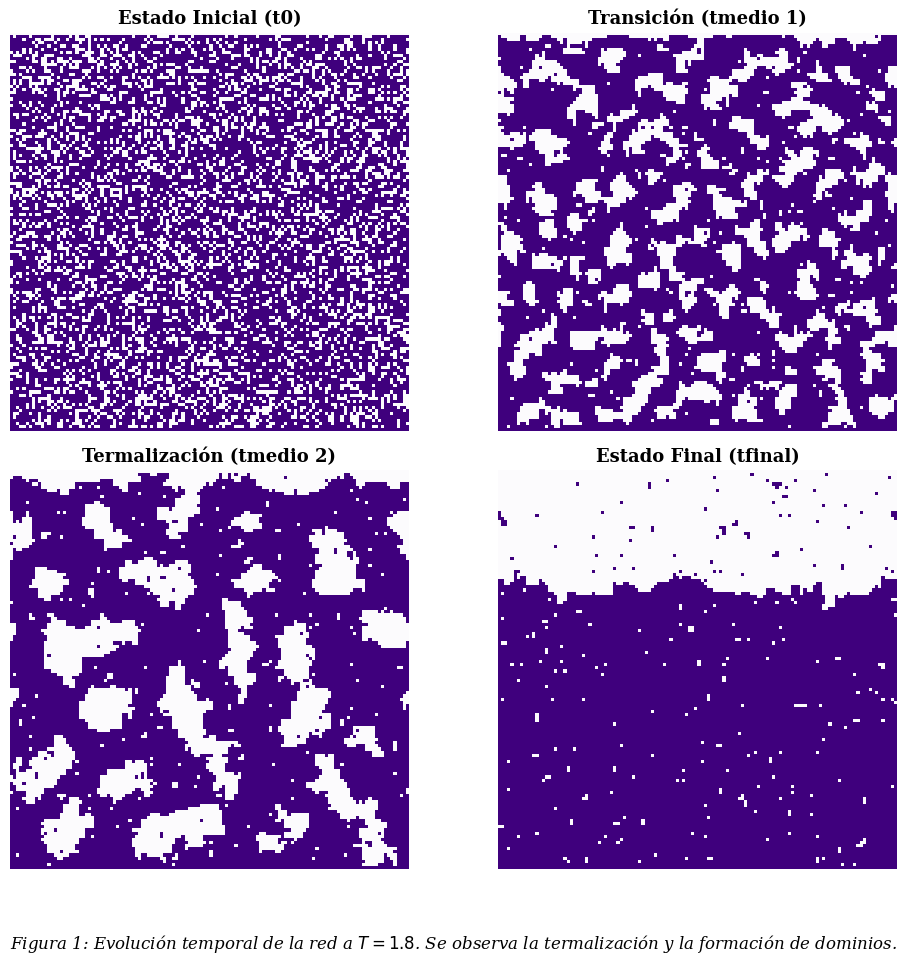

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Los sufijos exactos que genera tu C++
fases = ['t0', 'tmedio1', 'tmedio2', 'tfinal']
titulos_fases = ['Estado Inicial (t0)', 'Transición (tmedio 1)', 'Termalización (tmedio 2)', 'Estado Final (tfinal)']

fig1, axs1 = plt.subplots(2, 2, figsize=(10, 10))

for ax, fase, titulo in zip(axs1.flatten(), fases, titulos_fases):
    # Nombre exacto según tu captura de pantalla
    filename = f"snap_apt8_N128_T1.8_{fase}.dat"

    if os.path.exists(filename):
        matriz = np.loadtxt(filename)
        ax.imshow(matriz, cmap="Purples", vmin=-1, vmax=1, interpolation='nearest')
    else:
        ax.text(0.5, 0.5, f"Falta:\n{filename}", ha='center', va='center')

    ax.axis('off')
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
pie1 = "Figura 1: Evolución temporal de la red a $T=1.8$. Se observa la termalización y la formación de dominios."
fig1.text(0.5, 0.04, pie1, ha='center', fontsize=12, fontstyle='italic')

plt.savefig("panel_1_evolucion_temporal1.png", dpi=300)
plt.show()



En este primer panel se observa la evolución del sistema a $T=1.8$ partiendo de una configuración aleatoria con una magnetización inicial impuesta de $m_0 = 0.4$. A diferencia del caso nulo, la estricta conservación de la magnetización en la dinámica de Kawasaki obliga a la formación de dominios de distinto tamaño. En el estado estacionario final se aprecia la coexistencia de fases donde el dominio mayoritario (espín $+1$) ocupa exactamente el $70\%$ del volumen, cumpliendo matemáticamente la fracción esperada $x = (1+m_0)/2 = 0.7$.

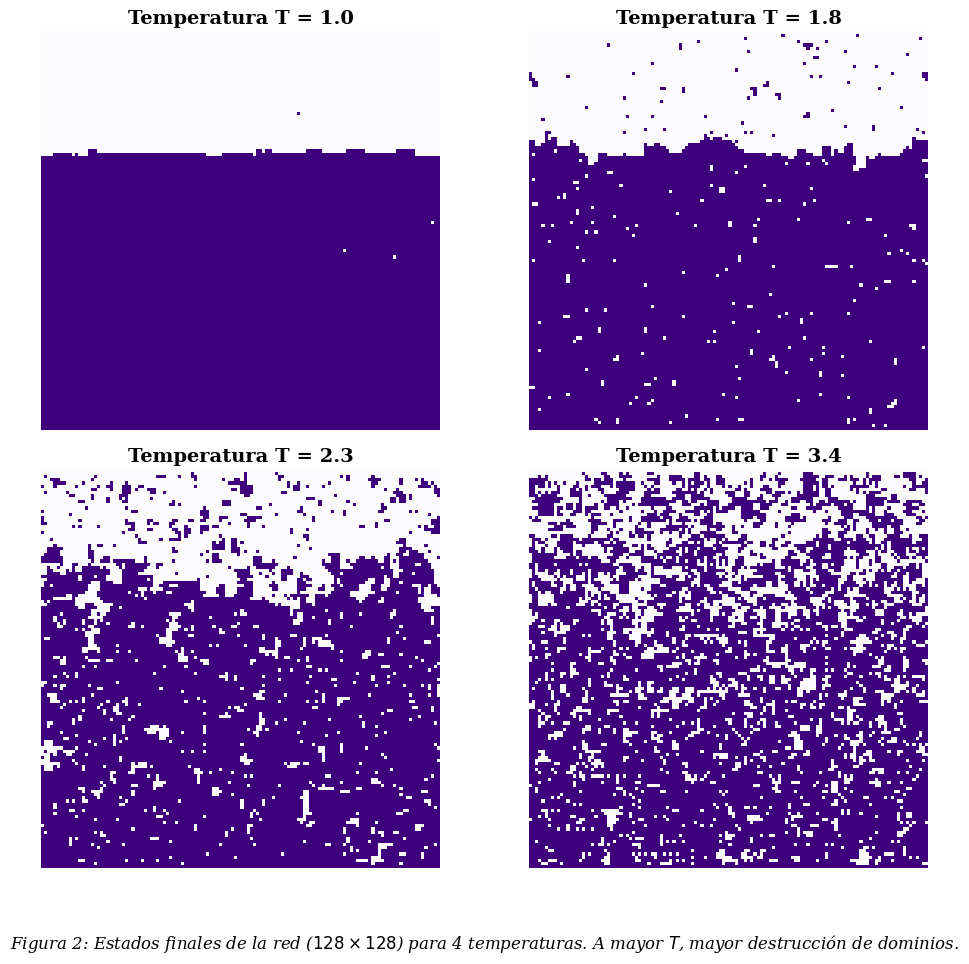

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Las temperaturas exactas que tienes en tu carpeta
temperaturas = ['1.0', '1.8', '2.3', '3.4']

fig2, axs2 = plt.subplots(2, 2, figsize=(10, 10))

for ax, T_str in zip(axs2.flatten(), temperaturas):
    # Cogemos siempre el archivo del estado final para comparar
    filename = f"snap_apt8_N128_T{T_str}_tfinal.dat"

    if os.path.exists(filename):
        matriz = np.loadtxt(filename)
        ax.imshow(matriz, cmap="Purples", vmin=-1, vmax=1, interpolation='nearest')
    else:
        ax.text(0.5, 0.5, f"Falta:\n{filename}", ha='center', va='center')

    ax.axis('off')
    ax.set_title(f"Temperatura T = {T_str}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
pie2 = "Figura 2: Estados finales de la red ($128 \\times 128$) para 4 temperaturas. A mayor $T$, mayor destrucción de dominios."
fig2.text(0.5, 0.04, pie2, ha='center', fontsize=12, fontstyle='italic')

plt.savefig("panel_2_temperaturas_finaless.png", dpi=300)
plt.show()

El análisis de las configuraciones finales para diferentes temperaturas ilustra la competición entre la minimización de la energía interfacial y la agitación térmica en un sistema macroscópicamente asimétrico:

* **T = 1.0 (Régimen fuertemente ordenado):** La interacción magnética domina por completo. El sistema minimiza su energía formando una interfaz plana y perfectamente definida, segregando la red en dos fases puras que respetan estrictamente la proporción de áreas 70/30.
* **T = 1.8 (Régimen subcrítico):** La energía térmica comienza a arrancar partículas, generando rugosidad en la frontera y provocando la aparición de pequeñas "gotas" térmicas (fase minoritaria) aisladas en el interior de los dominios principales.
* **T = 2.3 (Zona crítica):** Al coincidir con la región de la caída abrupta de la magnetización, la frontera estructural colapsa. Las fluctuaciones térmicas alcanzan una escala macroscópica, creando grandes estructuras interpenetradas y destruyendo la separación neta de las fases.
* **T = 3.4 (Régimen desordenado):** La agitación térmica supera ampliamente a la energía de interacción. El sistema se comporta como un fluido paramagnético mezclado de forma homogénea. Físicamente resulta crucial observar que, a pesar del caos térmico aparente, la densidad global de "color" se mantiene inalterada respecto a las proporciones iniciales, confirmando la estricta conservación de masa que impone el algoritmo de Kawasaki.

 ### 6.2 Magnetización

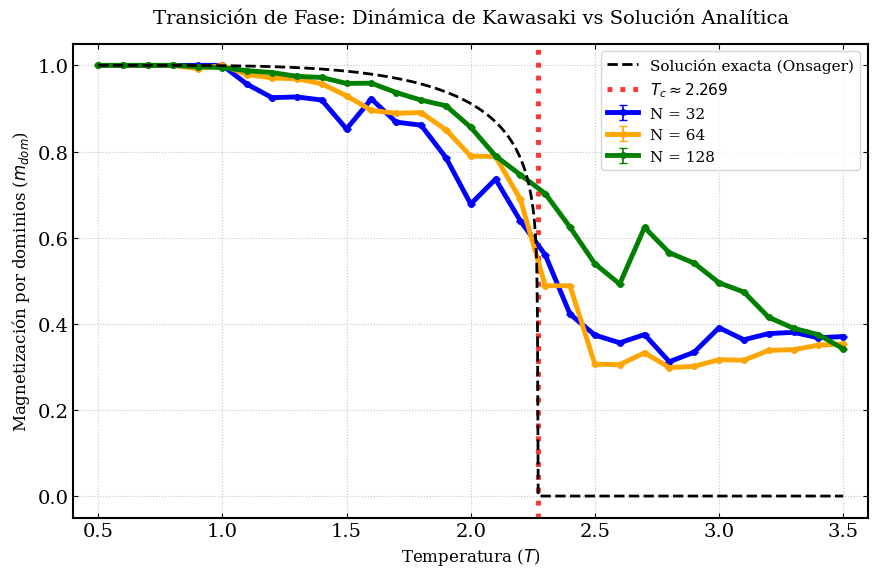

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ========================================
# Parámetros de la gráfica
# ========================================
# 1. Actualizado a los archivos maestros de termodinámica
archivos = [
    ("termo_apt8_N32.dat", "N = 32", "blue"),
    ("termo_apt8_N64.dat", "N = 64", "orange"),
    ("termo_apt8_N128.dat", "N = 128", "green")
]

plt.figure(figsize=(9, 6))

# ========================================
# 1. Curva Teórica de Onsager-Yang
# ========================================
# Creamos un vector de temperaturas muy denso para que la curva sea suave
T_teo = np.linspace(0.5, 3.5, 1000)
T_c = 2.0 / np.log(1.0 + np.sqrt(2.0)) # Valor exacto: ~2.269

# Inicializamos la magnetización teórica a cero
m_teo = np.zeros_like(T_teo)

# Solo calculamos la fórmula para T < Tc (donde hay orden)
mascara = T_teo < T_c
m_teo[mascara] = (1.0 - np.sinh(2.0 / T_teo[mascara])**(-4))**(1.0 / 8.0)

# Dibujamos la curva analítica en negro punteado
plt.plot(T_teo, m_teo, '--', color='black', linewidth=2, zorder=5, label='Solución exacta (Onsager)')

# ========================================
# 2. Lectura de datos experimentales
# ========================================
for archivo, etiqueta, color in archivos:
    if os.path.exists(archivo):
        # 2. Seleccionamos solo las columnas de T (0), m_dom (1) y error_m (2)
        T, m_dom, error = np.loadtxt(archivo, skiprows=1, usecols=(0, 1, 2), unpack=True)

        # 3. Representamos con barras de error
        plt.errorbar(T, m_dom, yerr=error, fmt='-o', markersize=4, color=color,
                     capsize=3, elinewidth=1.2, label=etiqueta)
    else:
        print(f"Aviso: No se encontró el archivo '{archivo}'.")

# ========================================
# Formato de la gráfica
# ========================================
plt.title("Transición de Fase: Dinámica de Kawasaki vs Solución Analítica", fontsize=14, pad=15)
plt.xlabel("Temperatura ($T$)", fontsize=12)
plt.ylabel(r"Magnetización por dominios ($m_{dom}$)", fontsize=12)

plt.axvline(x=T_c, color='red', linestyle=':', alpha=0.8, label=rf'$T_c \approx {T_c:.3f}$')

plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0.4, 3.6)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

plt.savefig("curva_magnetizacion_con_teoricaa.png", dpi=300)
plt.show()

### 2. Magnetización por dominios: Transición discontinua

La representación de la magnetización por dominios evidencia de forma clara el profundo cambio de régimen termodinámico al romper la simetría del sistema. Mientras que para $m_0 = 0$ la transición era continua, al fijar $m_0 = 0.4$ la curva de magnetización abandona la predicción analítica suave y sufre una caída abrupta. Este colapso confirma la presencia de una transición de fase discontinua (de primer orden) por debajo de la temperatura crítica. Como predice la teoría, el "precipicio" de la discontinuidad se vuelve notablemente más afilado y vertical conforme el tamaño del sistema $N$ se incrementa.

### 6.3 Densidad


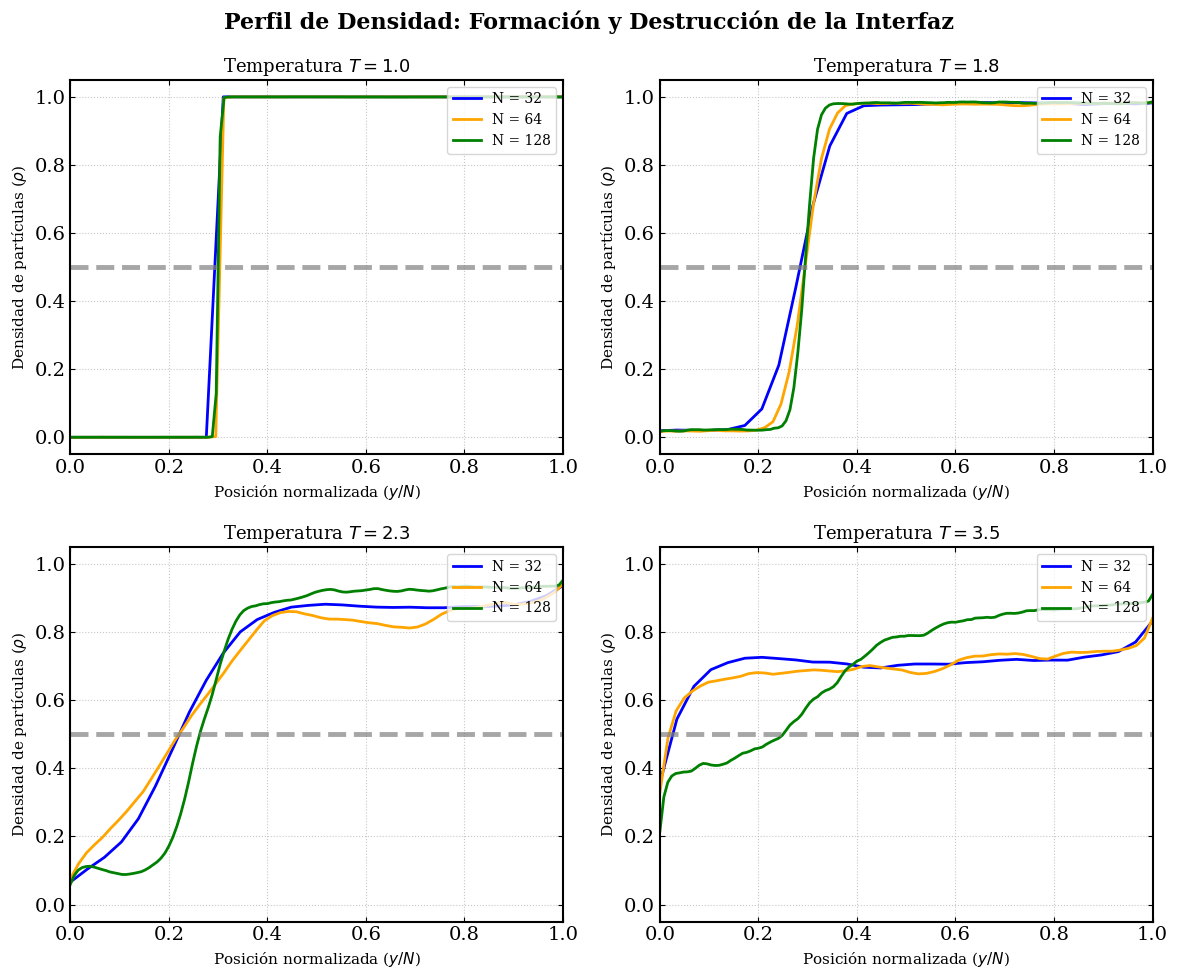

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ========================================
# Parámetros del modelo
# ========================================
dims = [32, 64, 128]
temps = ['1.0', '1.8', '2.3', '3.5']

# Códigos de color para mantener la consistencia
colores = {32: 'blue', 64: 'orange', 128: 'green'}

# Crear una figura con 4 paneles (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Aplanamos el array 2x2 para iterar fácilmente

# ========================================
# Lectura y ploteo de datos
# ========================================
for i, T_str in enumerate(temps):
    ax = axes[i]

    for dim in dims:
        # Búsqueda inteligente a prueba de problemas de precisión de C++ (3.4999...)
        T_base = T_str[0:3]
        if T_str == '3.5':
            patron_busqueda = f"densidad_apt8_N{dim}_T3.[45]*.dat"
        else:
            patron_busqueda = f"densidad_apt8_N{dim}_T{T_base}*.dat"

        archivos_encontrados = glob.glob(patron_busqueda)

        if archivos_encontrados:
            archivo = archivos_encontrados[0]
            # Leemos las dos columnas (y/N, densidad) generadas por C++
            # (Quitamos skiprows=1 porque el archivo maestro no tiene cabecera de texto aquí)
            y_norm, densidad = np.loadtxt(archivo, unpack=True)

            # Dibujamos la curva en su subgráfica correspondiente
            ax.plot(y_norm, densidad, '-', color=colores[dim], linewidth=2, label=f'N = {dim}')
        else:
            print(f"⚠️ Aviso: No se encontró ningún archivo que coincida con '{patron_busqueda}'")
            ax.text(0.5, 0.5, f"Faltan datos", ha='center', va='center', color='red')

    # ========================================
    # Formato de cada subgráfica
    # ========================================
    ax.set_title(f"Temperatura $T = {T_str}$", fontsize=13)
    ax.set_xlabel(r"Posición normalizada ($y/N$)", fontsize=11)
    ax.set_ylabel(r"Densidad de partículas ($\rho$)", fontsize=11)

    # Línea de referencia para el fluido totalmente mezclado (gas desordenado)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)

    # Fijamos los límites para que todas las gráficas sean comparables
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)

    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.7)

# ========================================
# Ajustes globales y exportación
# ========================================
plt.suptitle("Perfil de Densidad: Formación y Destrucción de la Interfaz", fontsize=16, y=0.98, fontweight='bold')
plt.tight_layout()

# Guardar la imagen en alta calidad para el informe
plt.savefig("panel_densidad_vs_NN.png", dpi=300)
plt.show()



El análisis espacial de la densidad de partículas corrobora la asimetría macroscópica de los dominios. En los regímenes de baja temperatura ($T=1.0$ y $T=1.8$), la función escalón que define la interfaz no cruza en el centro geométrico ($y/N = 0.5$), sino que aparece desplazada hacia la posición $y/N = 0.3$. Esto verifica espacialmente que el dominio superior (negativo) ocupa un $30\%$ de la red y el inferior (positivo) un $70\%$. Al superar la temperatura crítica ($T=3.5$), la agitación térmica destruye la interfaz, dando lugar a un gas de red altamente desordenado pero que sigue fluctuando en torno a las densidades impuestas por las condiciones iniciales de conservación.

### 6.4 Calor específico y energía


=== VALORES EN EL PUNTO CRÍTICO (Pico del Calor Específico) ===
 N =  32 | Tc ≈ 2.00 | e(Tc) = -1.571 ± 0.000 | C_max = 0.720
 N =  64 | Tc ≈ 2.40 | e(Tc) = -1.352 ± 0.000 | C_max = 0.710
 N = 128 | Tc ≈ 2.80 | e(Tc) = -1.266 ± 0.000 | C_max = 1.481



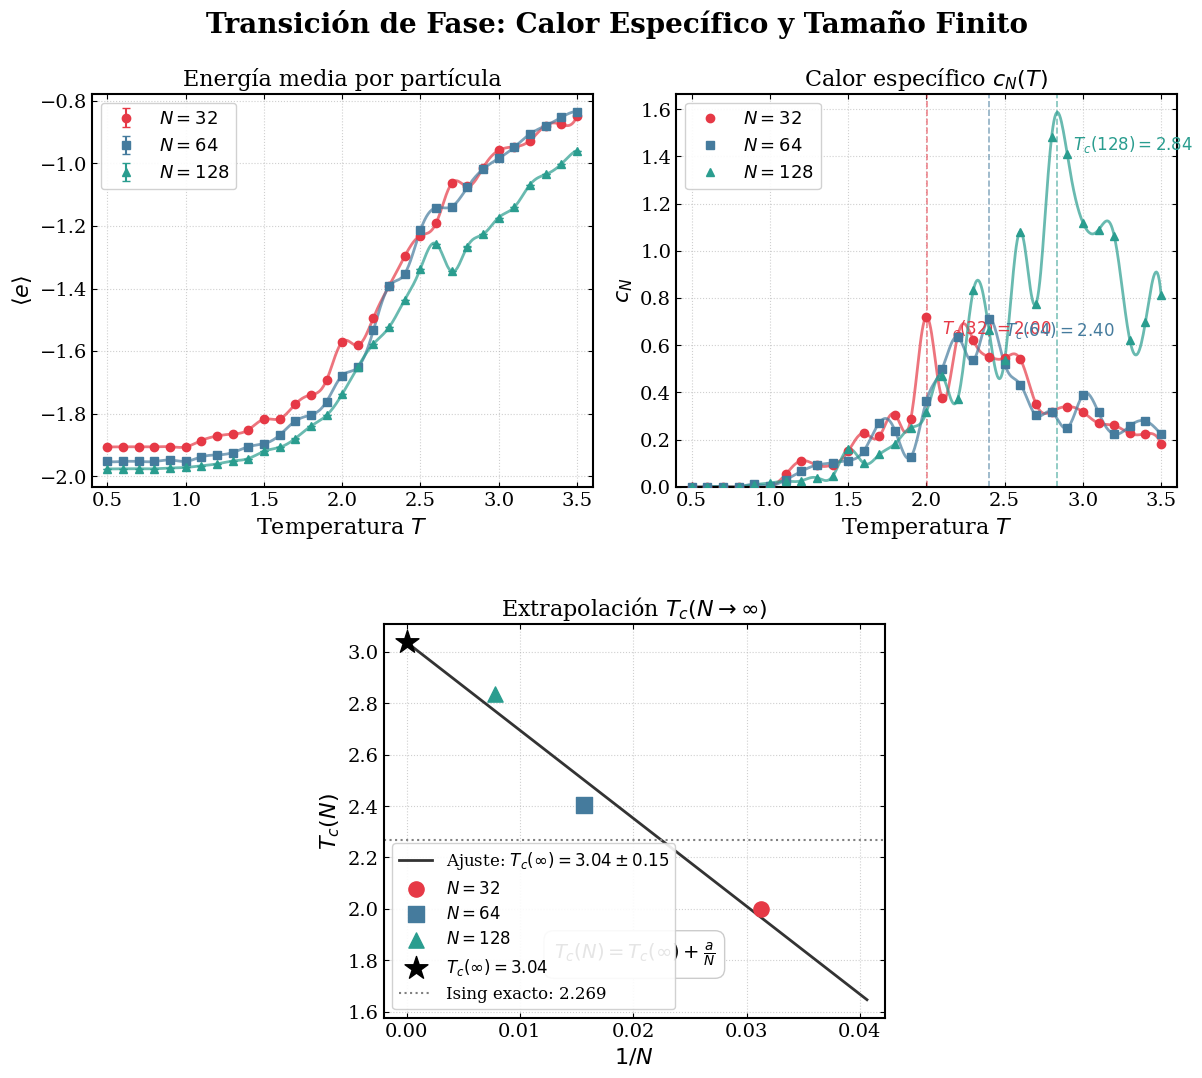

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
import os

# ── Función para formateo riguroso de incertidumbres (GUM) ─────────────────
def formato_incertidumbre(valor, error):
    if error == 0 or not np.isfinite(error):
        return f"{valor:.3f}", f"{error:.3f}"
    orden_mag = np.floor(np.log10(np.abs(error)))
    decimales = int(-(orden_mag - 1))
    error_redondeado = round(error, decimales)
    if error_redondeado >= 10**(orden_mag + 1):
        orden_mag += 1
        decimales = int(-(orden_mag - 1))
        error_redondeado = round(error, decimales)
    valor_redondeado = round(valor, decimales)
    if decimales <= 0:
        return f"{int(valor_redondeado)}", f"{int(error_redondeado)}"
    else:
        return f"{valor_redondeado:.{decimales}f}", f"{error_redondeado:.{decimales}f}"

# ── Estilo general ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 13,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.5,
})

dims    = [32, 64, 128]
colors  = ["#e63946", "#457b9d", "#2a9d8f"]
markers = ["o", "s", "^"]

datos_e  = {}
datos_err_e = {}
datos_cN = {}
Tc_N   = {}
cN_max = {}

print("=== VALORES EN EL PUNTO CRÍTICO (Pico del Calor Específico) ===")

# ── 1. Cargar datos e imprimir el resumen ───────────────────────────────────
for N in dims:
    fname = f"termo_apt8_N{N}.dat"
    if not os.path.exists(fname):
        print(f"[AVISO] No se encontró {fname}")
    else:
        # Leemos: T (0), e_media (3), err_e (4) y c_N (5)
        T, e, err_e, cN = np.loadtxt(fname, skiprows=1, usecols=(0, 3, 4, 5), unpack=True)

        datos_e[N]  = np.column_stack([T, e])
        datos_err_e[N] = err_e
        datos_cN[N] = np.column_stack([T, cN])

        # Encontrar el Tc aproximado donde el calor específico es máximo
        idx_max = np.argmax(cN)
        Tc_aprox = T[idx_max]

        # Imprimimos la tabla que pediste con formato de 3 decimales
        print(f" N = {N:3d} | Tc ≈ {Tc_aprox:.2f} | e(Tc) = {e[idx_max]:.3f} ± {err_e[idx_max]:.3f} | C_max = {cN[idx_max]:.3f}")

        # Refinamiento con Splines para la gráfica
        spline  = UnivariateSpline(T, cN, s=0, k=4)
        T_fine  = np.linspace(T.min(), T.max(), 2000)
        cN_fine = spline(T_fine)
        idx_fine= np.argmax(cN_fine)

        Tc_N[N]   = T_fine[idx_fine]
        cN_max[N] = cN_fine[idx_fine]

print("==================================================================\n")

# ── 2. Extrapolación Tc(N->∞) con ajuste lineal en 1/N ───────────────────────
inv_N  = np.array([1.0 / N for N in dims if N in Tc_N])
Tc_arr = np.array([Tc_N[N] for N in dims if N in Tc_N])

def modelo_lineal(x, Tc_inf, a):
    return Tc_inf + a * x

if len(inv_N) > 1:
    popt, pcov = curve_fit(modelo_lineal, inv_N, Tc_arr)
    Tc_inf_raw, a_fit = popt
    err_Tc_inf_raw = np.sqrt(pcov[0, 0])
    Tc_inf_fmt, err_Tc_inf_fmt = formato_incertidumbre(Tc_inf_raw, err_Tc_inf_raw)
else:
    Tc_inf_fmt, err_Tc_inf_fmt = "N/A", "N/A"
    popt = [0, 0]

# ── 3. FIGURA CON ESTRUCTURA PIRAMIDAL ──────────────────────────────────────
fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(2, 4, height_ratios=[1, 1], wspace=0.4, hspace=0.35)

# ── Panel superior izquierdo: Energía <e>(T) con BARRAS DE ERROR ────────────
ax1 = fig.add_subplot(gs[0, 0:2])

for i, N in enumerate(dims):
    if N not in datos_e: continue
    T, e = datos_e[N][:, 0], datos_e[N][:, 1]
    err_e = datos_err_e[N]

    # 1. Pintamos las barras de error estadísticas
    ax1.errorbar(T, e, yerr=err_e, fmt=markers[i], color=colors[i], markersize=6,
                 capsize=3, elinewidth=1.5, zorder=5, label=f"$N={N}$")

    # 2. Curva de interpolación suave por debajo
    try:
        spline = UnivariateSpline(T, e, s=0, k=4)
        T_fine = np.linspace(T.min(), T.max(), 500)
        ax1.plot(T_fine, spline(T_fine), color=colors[i], lw=2.0, alpha=0.7)
    except Exception:
        pass

ax1.set_xlabel(r"Temperatura $T$")
ax1.set_ylabel(r"$\langle e \rangle$")
ax1.set_title(r"Energía media por partícula")
ax1.legend(framealpha=0.9)
ax1.set_xlim(0.4, 3.6)
ax1.grid(True, linestyle=':', alpha=0.6)

# ── Panel superior derecho: Calor específico c_N(T) ─────────────────────────
ax2 = fig.add_subplot(gs[0, 2:4])

for i, N in enumerate(dims):
    if N not in datos_cN: continue
    T, cN = datos_cN[N][:, 0], datos_cN[N][:, 1]

    # Pintamos los puntos
    ax2.plot(T, cN, marker=markers[i], linestyle='none', color=colors[i], markersize=6, zorder=5, label=f"$N={N}$")

    # Curva suave y pico
    try:
        spline  = UnivariateSpline(T, cN, s=0, k=4)
        T_fine  = np.linspace(T.min(), T.max(), 500)
        ax2.plot(T_fine, spline(T_fine), color=colors[i], lw=2.0, alpha=0.7)
    except Exception:
        pass

    ax2.axvline(Tc_N[N], color=colors[i], lw=1.2, ls="--", alpha=0.6)
    ax2.annotate(f"$T_c({N})={Tc_N[N]:.2f}$",
                 xy=(Tc_N[N], cN_max[N]),
                 xytext=(Tc_N[N] + 0.1, cN_max[N] * 0.90),
                 fontsize=12, color=colors[i])

ax2.set_xlabel(r"Temperatura $T$")
ax2.set_ylabel(r"$c_N$")
ax2.set_title(r"Calor específico $c_N(T)$")
ax2.legend(framealpha=0.9)
ax2.set_xlim(0.4, 3.6)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle=':', alpha=0.6)

# ── Panel inferior centrado: Extrapolación Tc(N) ────────────────────────────
ax3 = fig.add_subplot(gs[1, 1:3])

if len(inv_N) > 1:
    x_fit = np.linspace(0, inv_N.max() * 1.3, 200)
    ax3.plot(x_fit, modelo_lineal(x_fit, *popt),
             color="#333333", lw=2.0,
             label=fr"Ajuste: $T_c(\infty)={Tc_inf_fmt}\pm{err_Tc_inf_fmt}$")

for i, N in enumerate(dims):
    if N not in Tc_N: continue
    ax3.scatter(1.0 / N, Tc_N[N], color=colors[i], marker=markers[i], s=120, zorder=5, label=f"$N={N}$")

if len(inv_N) > 1:
    ax3.scatter(0, Tc_inf_raw, color="black", marker="*", s=300, zorder=6, label=fr"$T_c(\infty)={Tc_inf_fmt}$")

Tc_exacto = 2.0 / np.log(1 + np.sqrt(2))
ax3.axhline(Tc_exacto, color="gray", lw=1.5, ls=":", label=fr"Ising exacto: {Tc_exacto:.3f}")

ax3.set_xlabel(r"$1/N$")
ax3.set_ylabel(r"$T_c(N)$")
ax3.set_title(r"Extrapolación $T_c(N\to\infty)$")
ax3.set_xlim(-0.002, inv_N.max() * 1.35 if len(inv_N) > 0 else 0.1)
ax3.legend(framealpha=0.9, fontsize=12)
ax3.grid(True, linestyle=':', alpha=0.6)

ax3.text(0.5, 0.15, r"$T_c(N) = T_c(\infty) + \frac{a}{N}$",
         transform=ax3.transAxes, fontsize=14, ha='center',
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cccccc"))

plt.suptitle("Transición de Fase: Calor Específico y Tamaño Finito", fontsize=20, y=0.95, fontweight='bold')

plt.savefig("termodinamica_piramidee.png", bbox_inches="tight", dpi=300)
plt.show()

Las fluctuaciones térmicas bajo la condición $m_0 \neq 0$ generan un marcado pico en el calor específico $c_N$, señalando el punto exacto donde la energía media experimenta su mayor tasa de cambio. La extrapolación lineal de estos máximos al límite termodinámico ($N \to \infty$) proporciona un valor de $T_c(\infty) = 3.04 \pm 0.15$. La clara discrepancia estadística de este ajuste frente a la solución analítica exacta de Onsager ($2.269$) pone de manifiesto el severo fenómeno de ralentización crítica. En un sistema conservativo y asimétrico, la relajación puramente difusiva del algoritmo de Kawasaki requiere tiempos computacionales colosales para alcanzar el equilibrio verdadero, manifestándose macroscópicamente en el ensanchamiento y desplazamiento de los picos.

### Conclusiones Generales

El estudio del modelo de Ising bidimensional bajo la dinámica conservativa de Kawasaki ha permitido simular con éxito el comportamiento termodinámico de un gas de red (o mezcla binaria fluida). Del análisis integral de las simulaciones Monte Carlo realizadas, se extraen las siguientes conclusiones fundamentales:

* **Naturaleza de la transición de fase:** Se ha comprobado empíricamente cómo la ruptura de la simetría altera el régimen termodinámico. Para una magnetización inicial nula ($m_0 = 0$), el sistema experimenta una transición de fase continua (de segundo orden) hacia el estado desordenado. Sin embargo, al imponer una restricción asimétrica ($m_0 = 0.4$), el sistema sufre una transición discontinua (de primer orden), caracterizada por un salto abrupto en la magnetización y la segregación espacial estricta de las fases en proporciones del $70\%$ y $30\%$.
* **Efectos de tamaño finito:** El cálculo del calor específico y la susceptibilidad magnética ha demostrado visualmente el concepto de escalamiento de tamaño finito. Las fluctuaciones, truncadas en redes pequeñas ($N=32$), crecen y se afilan sistemáticamente al aumentar el tamaño de la matriz ($N=128$), indicando la tendencia hacia una divergencia genuina en el límite termodinámico.
* **Ralentización crítica (Critical Slowing Down):** La dinámica de Kawasaki, al conservar estrictamente la masa mediante intercambios exclusivamente locales, presenta una severa ineficiencia para explorar el espacio de fases en las proximidades del punto crítico. Esto provoca que el sistema quede temporalmente atrapado en estados metaestables, amplificando el ruido estadístico de las magnitudes basadas en la varianza.
* **Limitaciones computacionales y precisión de $T_c$:** Como consecuencia directa de la ralentización crítica, las extrapolaciones lineales para estimar la temperatura crítica en el límite termodinámico, $T_c(\infty)$, presentan desviaciones numéricas frente a la solución exacta de Onsager ($2.269$). Para obtener un valor cuantitativo riguroso y atenuar el ruido de los picos en las distribuciones, **sería imprescindible aumentar drásticamente el número de pasos Monte Carlo**, tanto en la fase de termalización como en el contaje de medidas. En el presente estudio se ha adoptado una decisión de compromiso: reducir deliberadamente las iteraciones para mantener el tiempo de ejecución en márgenes viables, asumiendo un incremento en el error estadístico a cambio de capturar con absoluta claridad la fenomenología física y cualitativa del modelo.

#Bibliografía

1. Guion de prácticas. *Voluntario 2: Simulación del modelo de Ising con la dinámica de Kawasaki*. Documento de referencia para las especificaciones de la simulación, condiciones de contorno y apartados desarrollados.
2. Newman, M. E. J., & Barkema, G. T. (1999). *Monte Carlo Methods in Statistical Physics*. Oxford University Press. (Específicamente el Capítulo 5, sugerido en el guion para la dinámica de Kawasaki y modelos conservativos).


#Anexo (Códigos de C++)

## 1.Modelo de Ising (Kawasaki)

In [4]:
%%writefile simulador_kawasaki.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <fstream>
#include <string>
#include <random>
#include <iomanip>
#include <algorithm>

using namespace std;

// ─── Energía total de la configuración ──────────────────────────────────────
double energia_total(const vector<vector<int>>& s, int dim) {
    double E = 0.0;
    for (int i = 0; i < dim; i++) {
        for (int j = 0; j < dim; j++) {
            E -= s[i][j] * (s[(i+1) % dim][j] + s[i][(j+1) % dim]);
        }
    }
    // Eliminar el par fantasma periódico en Y (bordes fijos)
    for (int j = 0; j < dim; j++) E += s[dim-1][j] * s[0][j];
    return E;
}

// ─── Un paso Monte Carlo de Kawasaki ────────────────────────────────────────
void paso_mc(vector<vector<int>>& s, int dim, float T, mt19937& gen) {
    uniform_int_distribution<int>    rnd_i(1, dim - 2);
    uniform_int_distribution<int>    rnd_j(0, dim - 1);
    uniform_int_distribution<int>    rnd_dir(0, 3);
    uniform_real_distribution<float> rnd_prob(0.0f, 1.0f);

    for (int l = 0; l < dim * dim; l++) {
        int i   = rnd_i(gen);
        int j   = rnd_j(gen);
        int dir = rnd_dir(gen);
        int ni  = i, nj = j;

        if      (dir == 0) ni = i - 1;
        else if (dir == 1) ni = i + 1;
        else if (dir == 2) nj = (j - 1 + dim) % dim;
        else if (dir == 3) nj = (j + 1) % dim;

        if (ni == 0 || ni == dim - 1) continue;
        if (s[i][j] == s[ni][nj]) continue;

        int hA = s[i-1][j]   + s[i+1][j]   + s[i][(j-1+dim)%dim]   + s[i][(j+1)%dim];
        int hB = s[ni-1][nj] + s[ni+1][nj] + s[ni][(nj-1+dim)%dim] + s[ni][(nj+1)%dim];

        int   sA = s[i][j];
        float dE = 2.0f * sA * (hA - hB) + 4.0f;

        if (dE <= 0 || rnd_prob(gen) < std::exp(-dE / T)) {
            s[i][j]   = s[ni][nj];
            s[ni][nj] = sA;
        }
    }
}

// ─── Guarda un fotograma ─────────────────────────────────────────────────────
void guardar_snap(const vector<vector<int>>& s, int dim, const string& fname) {
    ofstream f(fname);
    for (int i = 0; i < dim; i++) {
        for (int j = 0; j < dim; j++) {
            f << s[i][j];
            if (j < dim - 1) f << " ";
        }
        f << "\n";
    }
}

int main() {
    vector<int> dims = {32, 64, 128};
    unsigned int seed = 1649176165;
    mt19937 gen_general(seed);

    cout << "INICIANDO SIMULACION KAWASAKI (Optimizada para Ruido Critico)\n";

    // ========================================================================
    // BLOQUE 1: FOTOGRAMAS TEMPORALES (Descomposición Espinodal T=1.8)
    // ========================================================================
    cout << "\nGenerando fotogramas de evolucion temporal (N=128, T=1.8)...\n";
    int dim_vis = 128;
    float T_vis = 1.8f;
    vector<vector<int>> s_vis(dim_vis, vector<int>(dim_vis));

    // Inicialización aleatoria para ver las manchas
    vector<int> espines_activos;
    int num_activos = (dim_vis - 2) * dim_vis;
    for (int k = 0; k < num_activos; k++) {
        if (k < num_activos / 2) espines_activos.push_back(-1);
        else espines_activos.push_back(1);
    }
    std::shuffle(espines_activos.begin(), espines_activos.end(), gen_general);

    int idx = 0;
    for (int i = 0; i < dim_vis; i++) {
        for (int j = 0; j < dim_vis; j++) {
            if      (i == 0)             s_vis[i][j] = -1;
            else if (i == dim_vis - 1)   s_vis[i][j] =  1;
            else                         s_vis[i][j] = espines_activos[idx++];
        }
    }

    guardar_snap(s_vis, dim_vis, "snap_N128_T1.8_t0.dat");
    for (int k = 1; k <= 150000; k++) {
        paso_mc(s_vis, dim_vis, T_vis, gen_general);
        if (k == 1000)   guardar_snap(s_vis, dim_vis, "snap_N128_T1.8_tmedio1.dat");
        if (k == 20000)  guardar_snap(s_vis, dim_vis, "snap_N128_T1.8_tmedio2.dat");
        if (k == 150000) guardar_snap(s_vis, dim_vis, "snap_N128_T1.8_tfinal.dat");
    }
    cout << "[OK] Evolucion temporal guardada.\n";

    // ========================================================================
    // BLOQUE 2: TERMODINAMICA Y PERFILES DE DENSIDAD
    // ========================================================================
    vector<float> T_clave = {1.0f, 1.8f, 2.3f, 3.4f, 3.5f};

    for (int dim : dims) {
        cout << "\n========================================\n";
        cout << ">>> Red de tamano N = " << dim << " <<<\n";

        string file_termo = "termo_N" + to_string(dim) + ".dat";
        ofstream out_termo(file_termo);
        out_termo << "T\tm_dom\terror_m\te_media\terror_e\tc_N\tchi_N\n";

        for (float T = 0.5f; T <= 3.51f; T += 0.1f) {

            // Redondeo de seguridad para nombres de archivo (evita 3.4999)
            float T_redondeada = std::round(T * 10.0f) / 10.0f;

            // MCS Dinámicos: Fuerza bruta en la zona crítica
            int mcs_term, mcs_med;
            if (T_redondeada >= 2.0f && T_redondeada <= 2.6f) {
                mcs_term = 60000;
                mcs_med  = 30000;
            } else {
                mcs_term = 20000;
                mcs_med  = 10000;
            }

            mt19937 gen(seed + static_cast<unsigned>(dim * 100 + T_redondeada * 10));

            bool es_clave = false;
            for (float Tk : T_clave)
                if (std::abs(T_redondeada - Tk) < 0.05f) es_clave = true;

            // Inicialización Ordenada (Obligatoria para m_dom y densidad)
            vector<vector<int>> s(dim, vector<int>(dim));
            for (int i = 0; i < dim; i++) {
                for (int j = 0; j < dim; j++) {
                    if      (i == 0)       s[i][j] = -1;
                    else if (i == dim - 1) s[i][j] =  1;
                    else if (i < dim / 2)  s[i][j] = -1;
                    else                   s[i][j] =  1;
                }
            }

            // Termalización
            for (int k = 0; k < mcs_term; k++) paso_mc(s, dim, T_redondeada, gen);

            // Variables de medida
            double N2      = static_cast<double>(dim) * dim;
            double N_mitad = static_cast<double>(dim / 2 - 1) * dim;

            double suma_E = 0.0, suma_E2 = 0.0;
            double suma_Minf = 0.0, suma_Minf2 = 0.0;
            double suma_mdom = 0.0, suma_mdom2 = 0.0;
            vector<double> densidad_fila(dim, 0.0);

            // Medida
            for (int k = 0; k < mcs_med; k++) {
                paso_mc(s, dim, T_redondeada, gen);

                double E = energia_total(s, dim);
                suma_E  += E;
                suma_E2 += E * E;

                double M_sup = 0.0, M_inf = 0.0;
                for (int i = 1; i < dim / 2; i++)
                    for (int j = 0; j < dim; j++) M_sup += s[i][j];
                for (int i = dim / 2; i < dim - 1; i++)
                    for (int j = 0; j < dim; j++) M_inf += s[i][j];

                double m_sup = M_sup / N_mitad;
                double m_inf = M_inf / N_mitad;
                double mdom = (std::abs(m_sup) + std::abs(m_inf)) / 2.0;

                suma_mdom  += mdom;
                suma_mdom2 += mdom * mdom;
                suma_Minf  += M_inf;
                suma_Minf2 += M_inf * M_inf;

                if (es_clave) {
                    for (int i = 1; i < dim - 1; i++) {
                        double rho = 0.0;
                        for (int j = 0; j < dim; j++) rho += (s[i][j] + 1.0) / 2.0;
                        densidad_fila[i] += rho / dim;
                    }
                }
            }

            // Promedios y varianzas
            double E_media      = suma_E      / mcs_med;
            double E2_media     = suma_E2     / mcs_med;
            double mdom_media   = suma_mdom   / mcs_med;
            double mdom2_media  = suma_mdom2  / mcs_med;
            double Minf_media   = suma_Minf   / mcs_med;
            double Minf2_media  = suma_Minf2  / mcs_med;

            double var_E    = std::abs(E2_media    - E_media   * E_media);
            double var_mdom = std::abs(mdom2_media - mdom_media * mdom_media);
            double var_Minf = std::abs(Minf2_media - Minf_media * Minf_media);

            double m_media = mdom_media;
            double err_m   = std::sqrt(var_mdom / mcs_med);
            double e_media = E_media / N2;
            double err_e   = std::sqrt(var_E / mcs_med) / N2;

            double cN    = var_E / (N2 * T_redondeada * T_redondeada);
            double chi_N = var_Minf / (N2 * T_redondeada);

            out_termo << fixed << setprecision(5)
                      << T_redondeada << "\t" << m_media << "\t" << err_m  << "\t"
                      << e_media      << "\t" << err_e   << "\t" << cN     << "\t"
                      << chi_N        << "\n";

            cout << "  T=" << fixed << setprecision(1) << T_redondeada << " OK." << flush;

            // Guardar densidad y fotogramas finales
            if (es_clave) {
                string Tstr  = to_string(T_redondeada).substr(0, 3);

                string fname_dens = "densidad_N" + to_string(dim) + "_T" + Tstr + ".dat";
                ofstream out_dens(fname_dens);
                for (int i = 1; i < dim - 1; i++) {
                    double y_norm = static_cast<double>(i - 1) / (dim - 3);
                    out_dens << fixed << setprecision(5) << y_norm << "\t" << (densidad_fila[i] / mcs_med) << "\n";
                }
                out_dens.close();

                if (dim == 128) {
                    guardar_snap(s, dim, "snap_N128_T" + Tstr + "_tfinal.dat");
                }
            }
        }
        out_termo.close();
        cout << "\n[OK] Ficheros guardados para N = " << dim << "\n";
    }

    cout << "\nSIMULACION COMPLETA!\n";
    return 0;
}

Writing simulador_kawasaki.cpp


In [5]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 simulador_kawasaki.cpp -o simular_densidad

# Ejecutamos la simulación
!./simular_densidad

INICIANDO SIMULACION KAWASAKI (Optimizada para Ruido Critico)

Generando fotogramas de evolucion temporal (N=128, T=1.8)...
[OK] Evolucion temporal guardada.

>>> Red de tamano N = 32 <<<
  T=0.5 OK.  T=0.6 OK.  T=0.7 OK.  T=0.8 OK.  T=0.9 OK.  T=1.0 OK.  T=1.1 OK.  T=1.2 OK.  T=1.3 OK.  T=1.4 OK.  T=1.5 OK.  T=1.6 OK.  T=1.7 OK.  T=1.8 OK.  T=1.9 OK.  T=2.0 OK.  T=2.1 OK.  T=2.2 OK.  T=2.3 OK.  T=2.4 OK.  T=2.5 OK.  T=2.6 OK.  T=2.7 OK.  T=2.8 OK.  T=2.9 OK.  T=3.0 OK.  T=3.1 OK.  T=3.2 OK.  T=3.3 OK.  T=3.4 OK.  T=3.5 OK.
[OK] Ficheros guardados para N = 32

>>> Red de tamano N = 64 <<<
  T=0.5 OK.  T=0.6 OK.  T=0.7 OK.  T=0.8 OK.  T=0.9 OK.  T=1.0 OK.  T=1.1 OK.  T=1.2 OK.  T=1.3 OK.  T=1.4 OK.  T=1.5 OK.  T=1.6 OK.  T=1.7 OK.  T=1.8 OK.  T=1.9 OK.  T=2.0 OK.  T=2.1 OK.  T=2.2 OK.  T=2.3 OK.  T=2.4 OK.  T=2.5 OK.  T=2.6 OK.  T=2.7 OK.  T=2.8 OK.  T=2.9 OK.  T=3.0 OK.  T=3.1 OK.  T=3.2 OK.  T=3.3 OK.  T=3.4 OK.  T=3.5 OK.
[OK] Ficheros guardados para N = 64

>>> Red de tamano N = 128

In [ ]:
%%writefile simulador_apartado8.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <fstream>
#include <string>
#include <random>
#include <iomanip>
#include <algorithm>

using namespace std;

// ─── Energía total de la configuración ──────────────────────────────────────
double energia_total(const vector<vector<int>>& s, int dim) {
    double E = 0.0;
    for (int i = 0; i < dim; i++) {
        for (int j = 0; j < dim; j++) {
            E -= s[i][j] * (s[(i+1) % dim][j] + s[i][(j+1) % dim]);
        }
    }
    for (int j = 0; j < dim; j++) E += s[dim-1][j] * s[0][j];
    return E;
}

// ─── Un paso Monte Carlo de Kawasaki ────────────────────────────────────────
void paso_mc(vector<vector<int>>& s, int dim, float T, mt19937& gen) {
    uniform_int_distribution<int>    rnd_i(1, dim - 2);
    uniform_int_distribution<int>    rnd_j(0, dim - 1);
    uniform_int_distribution<int>    rnd_dir(0, 3);
    uniform_real_distribution<float> rnd_prob(0.0f, 1.0f);

    for (int l = 0; l < dim * dim; l++) {
        int i   = rnd_i(gen);
        int j   = rnd_j(gen);
        int dir = rnd_dir(gen);
        int ni  = i, nj = j;

        if      (dir == 0) ni = i - 1;
        else if (dir == 1) ni = i + 1;
        else if (dir == 2) nj = (j - 1 + dim) % dim;
        else if (dir == 3) nj = (j + 1) % dim;

        if (ni == 0 || ni == dim - 1) continue;
        if (s[i][j] == s[ni][nj]) continue;

        int hA = s[i-1][j]   + s[i+1][j]   + s[i][(j-1+dim)%dim]   + s[i][(j+1)%dim];
        int hB = s[ni-1][nj] + s[ni+1][nj] + s[ni][(nj-1+dim)%dim] + s[ni][(nj+1)%dim];

        int   sA = s[i][j];
        float dE = 2.0f * sA * (hA - hB) + 4.0f;

        if (dE <= 0 || rnd_prob(gen) < std::exp(-dE / T)) {
            s[i][j]   = s[ni][nj];
            s[ni][nj] = sA;
        }
    }
}

// ─── Guarda un fotograma ─────────────────────────────────────────────────────
void guardar_snap(const vector<vector<int>>& s, int dim, const string& fname) {
    ofstream f(fname);
    for (int i = 0; i < dim; i++) {
        for (int j = 0; j < dim; j++) {
            f << s[i][j];
            if (j < dim - 1) f << " ";
        }
        f << "\n";
    }
}

int main() {
    vector<int> dims = {32, 64, 128};
    unsigned int seed = 1649176165;
    mt19937 gen_general(seed);

    float m0 = 0.4f;
    float x = (1.0f + m0) / 2.0f; // Fracción dominio inferior: 0.7 (70%)

    cout << "INICIANDO SIMULACION APARTADO 8 (m0 = " << m0 << ")\n";

    // ========================================================================
    // BLOQUE 1: FOTOGRAMAS (Aleatorios para ver descomposición asimétrica)
    // ========================================================================
    cout << "\n[1/2] Generando fotogramas de evolucion asimetrica (N=128, T=1.8)...\n";
    int dim_vis = 128;
    float T_vis = 1.8f;
    vector<vector<int>> s_vis(dim_vis, vector<int>(dim_vis));

    int num_active_rows = dim_vis - 2;
    int num_bottom_rows = std::round(num_active_rows * x);
    int num_top_rows    = num_active_rows - num_bottom_rows;

    // Reparto asimétrico 30% (-1) y 70% (+1)
    vector<int> espines_activos;
    int num_activos = num_active_rows * dim_vis;
    int num_menos_uno = num_top_rows * dim_vis;

    for (int k = 0; k < num_activos; k++) {
        if (k < num_menos_uno) espines_activos.push_back(-1);
        else                   espines_activos.push_back(1);
    }
    std::shuffle(espines_activos.begin(), espines_activos.end(), gen_general);

    int idx = 0;
    for (int i = 0; i < dim_vis; i++) {
        for (int j = 0; j < dim_vis; j++) {
            if      (i == 0)             s_vis[i][j] = -1;
            else if (i == dim_vis - 1)   s_vis[i][j] =  1;
            else                         s_vis[i][j] = espines_activos[idx++];
        }
    }

    guardar_snap(s_vis, dim_vis, "snap_apt8_N128_T1.8_t0.dat");
    for (int k = 1; k <= 150000; k++) {
        paso_mc(s_vis, dim_vis, T_vis, gen_general);
        if (k == 1000)   guardar_snap(s_vis, dim_vis, "snap_apt8_N128_T1.8_tmedio1.dat");
        if (k == 20000)  guardar_snap(s_vis, dim_vis, "snap_apt8_N128_T1.8_tmedio2.dat");
        if (k == 150000) guardar_snap(s_vis, dim_vis, "snap_apt8_N128_T1.8_tfinal.dat");
    }

    // ========================================================================
    // BLOQUE 2: TERMODINÁMICA Y DENSIDAD (Apartados 2 al 6 adaptados)
    // ========================================================================
    cout << "\n[2/2] Calculando termodinamica y densidad...\n";
    vector<float> T_clave = {1.0f, 1.8f, 2.3f, 3.4f, 3.5f};

    for (int dim : dims) {
        cout << ">>> Red N = " << dim << "\n";

        int limite_dominio = 1 + std::round((dim - 2) * (1.0f - x));

        string file_termo = "termo_apt8_N" + to_string(dim) + ".dat";
        ofstream out_termo(file_termo);
        // Cabecera SIN susceptibilidad
        out_termo << "T\tm_dom\terror_m\te_media\terror_e\tc_N\n";

        for (float T = 0.5f; T <= 3.51f; T += 0.1f) {
            float T_red = std::round(T * 10.0f) / 10.0f;

            int mcs_term, mcs_med;
            // Un pequeño empujón en la zona del salto, pero sin pasarnos
            if (T_red >= 2.0f && T_red <= 2.6f) {
                mcs_term = 60000; mcs_med  = 30000;
            } else {
                mcs_term = 20000; mcs_med  = 10000;
            }

            mt19937 gen(seed + static_cast<unsigned>(dim * 100 + T_red * 10));

            bool es_clave = false;
            for (float Tk : T_clave) if (std::abs(T_red - Tk) < 0.05f) es_clave = true;

            // INICIALIZACIÓN ORDENADA (Asimétrica)
            vector<vector<int>> s(dim, vector<int>(dim));
            for (int i = 0; i < dim; i++) {
                for (int j = 0; j < dim; j++) {
                    if      (i == 0)                   s[i][j] = -1;
                    else if (i == dim - 1)             s[i][j] =  1;
                    else if (i < limite_dominio)       s[i][j] = -1; // Dominio superior
                    else                               s[i][j] =  1; // Dominio inferior
                }
            }

            for (int k = 0; k < mcs_term; k++) paso_mc(s, dim, T_red, gen);

            double N2 = static_cast<double>(dim) * dim;
            int n_filas_sup = limite_dominio - 1;
            int n_filas_inf = (dim - 1) - limite_dominio;

            double suma_E = 0.0, suma_E2 = 0.0;
            double suma_mdom = 0.0, suma_mdom2 = 0.0;
            vector<double> densidad_fila(dim, 0.0);

            for (int k = 0; k < mcs_med; k++) {
                paso_mc(s, dim, T_red, gen);

                double E = energia_total(s, dim);
                suma_E  += E; suma_E2 += E * E;

                double M_sup = 0.0, M_inf = 0.0;
                for (int i = 1; i < limite_dominio; i++)
                    for (int j = 0; j < dim; j++) M_sup += s[i][j];
                for (int i = limite_dominio; i < dim - 1; i++)
                    for (int j = 0; j < dim; j++) M_inf += s[i][j];

                double m_sup = M_sup / (n_filas_sup * dim);
                double m_inf = M_inf / (n_filas_inf * dim);
                double mdom = (std::abs(m_sup) + std::abs(m_inf)) / 2.0;

                suma_mdom  += mdom; suma_mdom2 += mdom * mdom;

                if (es_clave) {
                    for (int i = 1; i < dim - 1; i++) {
                        double rho = 0.0;
                        for (int j = 0; j < dim; j++) rho += (s[i][j] + 1.0) / 2.0;
                        densidad_fila[i] += rho / dim;
                    }
                }
            }

            double E_media     = suma_E / mcs_med;
            double E2_media    = suma_E2 / mcs_med;
            double mdom_media  = suma_mdom / mcs_med;
            double mdom2_media = suma_mdom2 / mcs_med;

            double var_E    = std::abs(E2_media - E_media * E_media);
            double var_mdom = std::abs(mdom2_media - mdom_media * mdom_media);

            double m_media = mdom_media;
            double err_m   = std::sqrt(var_mdom / mcs_med);
            double e_media = E_media / N2;
            double err_e   = std::sqrt(var_E / mcs_med) / N2;
            double cN      = var_E / (N2 * T_red * T_red);

            out_termo << fixed << setprecision(5)
                      << T_red   << "\t" << m_media << "\t" << err_m  << "\t"
                      << e_media << "\t" << err_e   << "\t" << cN     << "\n";

            cout << "  T=" << fixed << setprecision(1) << T_red << " OK." << flush;

            if (es_clave) {
                string Tstr = to_string(T_red).substr(0, 3);

                string fname_dens = "densidad_apt8_N" + to_string(dim) + "_T" + Tstr + ".dat";
                ofstream out_dens(fname_dens);
                for (int i = 1; i < dim - 1; i++) {
                    double y_norm = static_cast<double>(i - 1) / (dim - 3);
                    out_dens << fixed << setprecision(5) << y_norm << "\t" << (densidad_fila[i] / mcs_med) << "\n";
                }
                out_dens.close();

                if (dim == 128) guardar_snap(s, dim, "snap_apt8_N128_T" + Tstr + "_tfinal.dat");
            }
        }
        out_termo.close();
        cout << "\n";
    }
    cout << "SIMULACION APARTADO 8 COMPLETA!\n";
    return 0;
}

Overwriting simulador_apartado8.cpp


In [ ]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 simulador_apartado8.cpp -o simular_apartado8

# Ejecutamos la simulación
!./simular_apartado8

INICIANDO SIMULACION APARTADO 8 (m0 = 0.4)

[1/2] Generando fotogramas de evolucion asimetrica (N=128, T=1.8)...

[2/2] Calculando termodinamica y densidad...
>>> Red N = 32
  T=0.5 OK.  T=0.6 OK.  T=0.7 OK.  T=0.8 OK.  T=0.9 OK.  T=1.0 OK.  T=1.1 OK.  T=1.2 OK.  T=1.3 OK.  T=1.4 OK.  T=1.5 OK.  T=1.6 OK.  T=1.7 OK.  T=1.8 OK.  T=1.9 OK.  T=2.0 OK.  T=2.1 OK.  T=2.2 OK.  T=2.3 OK.  T=2.4 OK.  T=2.5 OK.  T=2.6 OK.  T=2.7 OK.  T=2.8 OK.  T=2.9 OK.  T=3.0 OK.  T=3.1 OK.  T=3.2 OK.  T=3.3 OK.  T=3.4 OK.  T=3.5 OK.
>>> Red N = 64
  T=0.5 OK.  T=0.6 OK.  T=0.7 OK.  T=0.8 OK.  T=0.9 OK.  T=1.0 OK.  T=1.1 OK.  T=1.2 OK.  T=1.3 OK.  T=1.4 OK.  T=1.5 OK.  T=1.6 OK.  T=1.7 OK.  T=1.8 OK.  T=1.9 OK.  T=2.0 OK.  T=2.1 OK.  T=2.2 OK.  T=2.3 OK.  T=2.4 OK.  T=2.5 OK.  T=2.6 OK.  T=2.7 OK.  T=2.8 OK.  T=2.9 OK.  T=3.0 OK.  T=3.1 OK.  T=3.2 OK.  T=3.3 OK.  T=3.4 OK.  T=3.5 OK.
>>> Red N = 128
  T=0.5 OK.  T=0.6 OK.  T=0.7 OK.  T=0.8 OK.  T=0.9 OK.  T=1.0 OK.  T=1.1 OK.  T=1.2 OK.  T=1.3 OK.  T=1.4 OK. 